In [1]:
# Setup and load modules
%load_ext autoreload
%autoreload 2

import astroflow as af
import unyt
import yt
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import numpy as np
from scipy.optimize import curve_fit
from unyt import unyt_array, unyt_quantity
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
import json
from datetime import datetime
from scipy.ndimage import gaussian_filter
from Hdecompose.atomic_frac import atomic_frac
import astropy.units as U
import astropy.constants as const
import os
from dataclasses import dataclass
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable                

gadgetUnitsCosmo = {
    "UnitLength_in_cm": 3.0868e+24,
    "UnitMass_in_g": 1.989e+43,
    "UnitVelocity_in_cm_per_s": 100000,
}

log = af.get_logger("Dwarfs Kinematics")
af.log.set_log_level("INFO")

def make_phase_filter(name, temp_threshold):
    @yt.particle_filter(f"{name}", requires=["Temperature"], filtered_type="PartType0")
    def temp_below_threshold(pfilter, data):
        filter = data[pfilter.filtered_type, "Temperature"] < temp_threshold
        return filter
    return temp_below_threshold

make_phase_filter("cold_gas", 2e4)

def _density_squared(field, data):
    return data[("PartType0", "Density")]**2

def _HI_density(field, data):
    if ("PartType0", "atomic_frac") not in data.ds.field_info:
        return data[("PartType0", "HI")] * data[("PartType0", "Density")] * (1 - data[("PartType0", "Metallicity")])
    else:
        return data[("PartType0", "atomic_frac")] * data[("PartType0", "Density")]

def _HI_mass(field, data):
    if ("PartType0", "atomic_frac") not in data.ds.field_info:
        return data[("PartType0", "HI")] * data[("PartType0", "Masses")] * (1 - data[("PartType0", "Metallicity")])
    else:
        return data[("PartType0", "atomic_frac")] * data[("PartType0", "Masses")] 

def _Rahmati_HI(field, data):
    """Rahmati et al. 2013 fitting formula for HI fraction based on density, temperature, and redshift."""
    z = float(data.ds.current_redshift)
    fH_init = 0.752 
    proton_mass_cgs = const.m_p.cgs 

    nH = data[("PartType0", "Density")].to("g/cm**3") * U.g / (U.cm ** 3) * (1 - data[("PartType0", "Metallicity")]) * fH_init / (proton_mass_cgs)
    rho = data[("PartType0", "Density")].to("g/cm**3") * U.g / (U.cm ** 3)
    Temp = data[("PartType0", "Temperature")].to("K").v * U.K

    return atomic_frac(redshift=z, nH=nH, T=Temp, rho=rho, Habundance = None, onlyA1=False, local = False)

# Setup hook: runs per snapshot during load
def setup_agora_snapshot(sim, idx):
    ds = sim[idx]
    bar = yt.data_objects.unions.ParticleUnion("baryon", ["PartType0", "PartType4"])
    ds.add_particle_union(bar)
    ds.add_field(("PartType0", "density_squared"), function=_density_squared, units="g**2/cm**6",
                 sampling_type="particle", force_override=True)
    if not ("PartType0", "HI") in ds.field_info:
        ds.add_field(("PartType0", "atomic_frac"), function=_Rahmati_HI, display_name="HI Fraction",
                    units="", sampling_type="particle", force_override=True, take_log=True)

    ds.add_field(("PartType0", "HI_density"), function=_HI_density, display_name="HI Density",
                    units="Msun/pc**3", sampling_type="particle", force_override=True, take_log=True)
    ds.add_field(("PartType0", "HI_mass"), function=_HI_mass, display_name="HI Mass",
                units="Msun", sampling_type="particle", force_override=True, take_log=True)
    ds.add_particle_filter("cold_gas")

def resolve_radius(s, altsim=None): 
    radius = s.v.r1_cgas.to_value() if altsim is None else altsim.v.r1_cgas.to_value() # kpc
    # If radius too small (e.g. no cold gas), fallback to stellar radius
    if radius < 0.1:
        radius = s.v.r1_star.to_value() if altsim is None else altsim.v.r1_star.to_value()
        if radius < 0.1:
            log.warning(f"Radius for kinematic calculations is very small ({radius:.3f} kpc). Check if cold gas or stars are present. Using half star radius as fallback.")
            radius = s.v.r_half_star.to_value() if altsim is None else altsim.v.r_half_star.to_value()
            if radius < 0.1:
                log.warning(f"Radius for kinematic calculations is still very small ({radius:.3f} kpc) after fallback to half star radius. Check if any particles are present. Using 0.1 kpc.")
                radius = 0.1
    return radius

# Core properties for simulations

def calc_core_prop(s, altsim=None):
    s.d.virial_radius_crit(force_recompute=False, center = s.v.center, label = "r_virial", auto_save=False)
    s.d.virial_radius_mean(force_recompute=False, center = s.v.center, label = "r_virial_mean", auto_save=False)
    s.d.virial_radius_BN(force_recompute=False, center = s.v.center, label = "r_virial_BN", auto_save=False)
    s.d.radius_e_dm(force_recompute=False, center = s.v.center, label = "r_half_dm", auto_save=False)
    s.d.mass_200(force_recompute=False, center = s.v.center, label = "m_200_all", auto_save=False, particle="all")
    s.d.mass_200(force_recompute=False, center = s.v.center, label = "m_200_dm", auto_save=False, particle="PartType1")
    
    _ = s.ds.index
    if ("PartType0", "Masses") in s.ds.field_info:
        s.d.radius_e_star(force_recompute=False, center = s.v.center, label = "r_half_star", auto_save=False)
        s.d.radius_e_gas(force_recompute=False, center = s.v.center, label = "r_half_gas", auto_save=False)
        s.d.mass_200(force_recompute=False, center = s.v.center, label = "m_200_star", auto_save=False, particle="PartType4")
        s.d.mass_200(force_recompute=False, center = s.v.center, label = "m_200_gas", auto_save=False, particle="PartType0")
        s.d.mass_200(force_recompute=False, center = s.v.center, label = "m_200_cgas", auto_save=False, particle="cold_gas")

        s.d.percent_mass_radius(force_recompute=False, center = s.v.center, label = "r_star_95", particle = "PartType4", percent = 0.95, auto_save=False)
        s.d.percent_mass_radius(force_recompute=False, center = s.v.center, label = "r_cgas_95", particle = "cold_gas", percent = 0.95, auto_save=False)
        s.d.percent_mass_radius(force_recompute=False, center = s.v.center, label = "r_all_95", particle = "all", percent = 0.95, auto_save=False)

    pcalcaxis = "cold_gas" if ("PartType0", "Masses") in s.ds.field_info else "PartType1"
    ang_radius = s.v.r_half_star.to_value() if altsim is None else altsim.v.r_half_star.to_value()
    
    s.d.faceon(force_recompute=False, radius = 2*ang_radius, use_particle=True, gas=False, particle=pcalcaxis, temp=None, center = s.v.center, label = "faceon", auto_save=False)
    s.d.edgeon(force_recompute=False, radius = 2*ang_radius, use_particle=True, gas=False, particle=pcalcaxis, temp=None, center = s.v.center, label = "edgeon", auto_save=False)

    if ("PartType0", "Masses") in s.ds.field_info:
        s.d.R_den(force_recompute=False, center=s.v.center, particle="cold_gas", radius=100, density_thresh=1e0, bins=40, axis=s.v.faceon, label="r1_cgas", auto_save=False)
        s.d.R_den(force_recompute=False, center=s.v.center, particle="PartType4", radius=100, density_thresh=1e0, bins=40, axis=s.v.faceon, label="r1_star", auto_save=False)
        s.d.R_den(force_recompute=False, center=s.v.center, particle="PartType0", radius=100, density_thresh=1e0, bins=40, axis=s.v.faceon, label="r1_gas", auto_save=False)

        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_cgas.to_value(), particle="cold_gas", label="m_r1_cgas", auto_save=False)
        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_cgas.to_value(), particle="PartType4", label="m_r1_star", auto_save=False)
        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_cgas.to_value(), particle="PartType0", label="m_r1_gas", auto_save=False)
        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_cgas.to_value(), particle="PartType1", label="m_r1_dm", auto_save=False)

        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_gas.to_value(), particle="cold_gas", label="m_r1gas_cgas", auto_save=False)
        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_gas.to_value(), particle="PartType4", label="m_r1gas_star", auto_save=False)
        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_gas.to_value(), particle="PartType0", label="m_r1gas_gas", auto_save=False)
        s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r1_gas.to_value(), particle="PartType1", label="m_r1gas_dm", auto_save=False)

        s.d.R_den(force_recompute=False, center=s.v.center, particle="cold_gas", radius=100, density_thresh=1e-1, bins=40, axis=s.v.faceon, label="r01_cgas", auto_save=False)

    ang_radius_2 = s.v.r1_cgas.to_value() if altsim is None else altsim.v.r1_cgas.to_value()

    s.d.faceon(force_recompute=False, radius = ang_radius_2, use_particle=True, gas=False, particle=pcalcaxis, temp=None, center = s.v.center, label = "faceon_r1", auto_save=False)
    s.d.edgeon(force_recompute=False, radius = ang_radius_2, use_particle=True, gas=False, particle=pcalcaxis, temp=None, center = s.v.center, label = "edgeon_r1", auto_save=False)

# Core kinematic for simulations

def calc_kinematic_prop(s, altsim=None):
    pcalc = "cold_gas" if ("PartType0", "Masses") in s.ds.field_info else "PartType1"
    radius = s.v.r1_cgas.to_value() if altsim is None else altsim.v.r1_cgas.to_value() # kpc

    # If radius too small (e.g. no cold gas), fallback to stellar radius
    if radius < 0.1:
        radius = s.v.r1_star.to_value() if altsim is None else altsim.v.r1_star.to_value()
        if radius < 0.1:
            log.warning(f"Radius for kinematic calculations is very small ({radius:.3f} kpc). Check if cold gas or stars are present. Using half star radius as fallback.")
            radius = s.v.r_half_star.to_value() if altsim is None else altsim.v.r_half_star.to_value()
            if radius < 0.1:
                log.warning(f"Radius for kinematic calculations is still very small ({radius:.3f} kpc) after fallback to half star radius. Check if any particles are present. Using 0.1 kpc.")
                radius = 0.1

    s.d.bulk_v(force_recompute=False, center = s.v.center, label = "v_bulk", radius = radius, auto_save=False, bv_kwargs={"use_gas":False,"use_particles":True, "particle_type":pcalc})
    s.d.v_max(force_recompute=False, center = s.v.center, label = "v_max", radius = radius, auto_save=False, particle="all", bins=50)
    s.t.r_fid(s.v.v_max/35)
    s.d.v_fid(force_recompute=False, center = s.v.center, label = "v_fid", radius = s.v.r_fid.to_value(), auto_save=False, particle="all")
    s.d.cuspyness(force_recompute=False, center = s.v.center, label = "alpha", radius = s.v.r_fid.to_value(), auto_save=False, particle="all", bins=50)
    s.t.eta_rot(s.v.v_fid / s.v.v_max)

    _ = s.ds.index
    if ("PartType0", "Masses") in s.ds.field_info:
        s.d.v_fid(force_recompute=False, center = s.v.center, label = "v_fid_bar", radius = s.v.r_fid.to_value(), auto_save=False, particle="baryon")
        s.t.eta_bar((s.v.v_fid_bar / s.v.v_fid)**2)
        s.d.v_phi(force_recompute=False, center = s.v.center, label = "v_phi", radius = s.v.r_fid.to_value(), auto_save=False, bulk_v = s.v.v_bulk, axis = s.v.faceon, particle="cold_gas")
        s.d.v_disp(force_recompute=False, center = s.v.center, label = "disp_phi", radius = s.v.r_fid.to_value(), auto_save=False, bulk_v = s.v.v_bulk, axis = s.v.faceon, particle="cold_gas")
        s.t.v_sigma(s.v.v_phi / s.v.disp_phi)
        s.d.sfr_young_star(force_recompute=False, center = s.v.center, radius = s.v.r_virial.to_value(), max_age = 20, auto_save=False, label = "sfr_young_star")
        s.t.ssfr(s.v.sfr_young_star / s.v.m_200_star)

def adaptive_bin_merging(edges, mid, counts, min_particles=50, local_log = log):
    """Generalized agglomerative binning for any 1D coordinate."""
    mid_adapt, edges_adapt, counts_adapt = [], [edges[0]], []
    curr_cnt, curr_sum = 0, 0.0
    
    for i in range(len(mid)):
        curr_cnt += counts[i]
        curr_sum += mid[i] * counts[i]
        if curr_cnt >= min_particles or i == len(mid) - 1:
            mid_adapt.append(curr_sum / curr_cnt if curr_cnt > 0 else mid[i])
            edges_adapt.append(edges[i+1])
            counts_adapt.append(curr_cnt)
            curr_cnt, curr_sum = 0, 0.0
    
    # Warn if min particle numbers is not reached 
    if counts_adapt[-1] < min_particles:
        local_log.warning(f"Outermost bin is starved! Out of desired {min_particles}, only {counts_adapt[-1]} were reached")
        local_log.warning(f"Full particle count per bin is: {counts_adapt}")
            
    return np.array(edges_adapt), np.array(mid_adapt), np.array(counts_adapt)

def build_bins(data, ptype, field, nbins, extrema = None, log_x = False, min_particles = 50, unit = None):
    profile = af.data.profile(data, (ptype,field), (ptype,"particle_ones"), data_args=af.settings.DataConfig(n_bins=nbins, bin_extrema=extrema, log = log_x, accumulate=False, weight_field=None, x_unit = unit))
    amount_of_p = profile[(ptype,"particle_ones")].v
    edge, mid, _ = adaptive_bin_merging(profile.x_bins.v, profile.x.v, amount_of_p, min_particles = min_particles)

    return {"set_bins": [edge], "x_data": unyt_array(mid, profile.x.units)}

# Load simulations
g4_paths = [
    (r"C:\Home\Astro\TFG\Data\AGORA\G4\snapshot_336.hdf5", "GADGET4-AGORA-1e10q"),
    (r"C:\Home\Astro\TFG\Data\kazuki\agora_1e10q_lv10\snapshot_275.hdf5", "GADGET4-CDwarf-1e10q"),
    (r"C:\Home\Astro\TFG\Data\kazuki\agora_1e10v_lv10\snapshot_275.hdf5", "GADGET4-CDwarf-1e10v"),
    *[(fr"C:\Home\Astro\TFG\Data\kazuki\halo{idx}\snapshot_275.hdf5", f"GADGET4-CDwarf-halo{idx}") for idx in [185, 196, 211, 224, 234, 256, 273, 291, 307, 316, 324]]
]

g4_dm_paths = [
    (r"C:\Home\Astro\TFG\Data\kazuki\dm_only\agora_1e10q_lv10\snapshot_016.hdf5", "GADGET4-CDwarf-DM-1e10q"),
    (r"C:\Home\Astro\TFG\Data\kazuki\dm_only\agora_1e10v_lv10\snapshot_016.hdf5", "GADGET4-CDwarf-DM-1e10v"),
    *[(fr"C:\Home\Astro\TFG\Data\kazuki\dm_only\halo{idx}\snapshot_016.hdf5", f"GADGET4-CDwarf-DM-halo{idx}") for idx in [185, 196, 211, 224, 234, 256, 273, 291, 307, 316, 324]]
]

g4 = [af.load(path, name, unit_base=gadgetUnitsCosmo, setup_hooks=[setup_agora_snapshot]) for path, name in g4_paths]
g4_dm = [af.load(path, name, unit_base=gadgetUnitsCosmo) for path, name in g4_dm_paths]
g4_dm.insert(0, g4_dm[0])  # Duplicate DM-1e10q since it's the same for AGORA run

# AREPO-T AGORA simulations
esn = [20,20,20,27,27,27,81,81,81,81]
thot = [3,5,10,8,12,16,1,4,12,16]
arepo = []
for i in range(len(esn)):
    name = f"e{esn[i]}t{str(thot[i]).zfill(2)}"
    arepo.append(af.load(fr"C:\Home\Astro\TFG\Data\arepo\{name}\snap_336.hdf5", f"AREPOT-AGORA-{name}", unit_base = gadgetUnitsCosmo, setup_hooks=[setup_agora_snapshot]))
arepo_dm = af.load("C:\\Home\\Astro\\TFG\\Data\\arepo\\dm_only\\snap_336.hdf5", "AREPOT-AGORA-DM", unit_base = gadgetUnitsCosmo)


Astroflow : [INFO] 2026-05-27 17:50:09,745 Logging level set to DEBUG
Astroflow : [INFO] 2026-05-27 17:50:11,466 Logging level set to INFO
Astroflow : [INFO] 2026-05-27 17:50:11,475 Simulation 'GADGET4-AGORA-1e10q' found in registry. Loading metadata
yt : [INFO     ] 2026-05-27 17:50:12,375 Calculating time from 1.000e+00 to be 4.355e+17 seconds
yt : [INFO     ] 2026-05-27 17:50:12,492 Parameters: current_time              = 4.35455710880514e+17 s
yt : [INFO     ] 2026-05-27 17:50:12,493 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-05-27 17:50:12,495 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-27 17:50:12,499 Parameters: domain_right_edge         = [5. 5. 5.]
yt : [INFO     ] 2026-05-27 17:50:12,501 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-05-27 17:50:12,502 Parameters: current_redshift          = 0.0
yt : [INFO     ] 2026-05-27 17:50:12,504 Parameters: omega_lambda              = 0.728
yt : [INFO     ] 

In [2]:
# Observational stuff
@dataclass
class Obs_Galaxy:
    name: str
    v_max: float;          e_v_max: float
    v_flat: float;         e_v_flat: float
    w20: float;            e_w20: float
    w50: float;            e_w50: float
    m_star: float;         e_m_star: float
    m_halo: float;        e_m_halo: float
    RHI: float;            
    MHI: float;            
    Fg: float
    r_1_2_star: float;     
    r_disk: float;         
    rad_profile: np.ndarray
    v_obs_profile: np.ndarray; e_v_obs_profile: np.ndarray
    v_gas_profile: np.ndarray
    v_disk_profile: np.ndarray
    v_bulge_profile: np.ndarray
    v_bar_profile: np.ndarray
    v_fid: float;          e_v_fid: float
    quality: int
    eta_rot: float;        e_eta_rot: float
    eta_bar: float        
    inclination: float
    m_bar: float;          e_m_bar: float
    # LITTLE THINGS properties
    v_disp_profile: np.ndarray
    sdens_profile: np.ndarray
    alpha: float;          e_alpha: float
    rad_dens_profile: np.ndarray = None

# ====================================================================
# PARSING & ERROR PROPAGATION ROUTINE
# ====================================================================
def load_sparc_data(table1_path, btfr2019_path, btfr2016_path, massmodels_path):
    
    def get_data_lines(filepath):
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_idx = next(i for i, line in enumerate(lines) if line.startswith('-------')) + 1
        return [l.strip() for l in lines[start_idx:] if l.strip()]

    def safe_float(val, replace_zero=False):
        try:
            v = float(val)
            return np.nan if replace_zero and v == 0.0 else v
        except ValueError:
            return np.nan

    # 1. Parse Table 1 (SPARC_Lelli2016c.mrt.txt)
    t1_data = {}
    for line in get_data_lines(table1_path):
        parts = line.split()
        if len(parts) >= 18:
            t1_data[parts[0]] = {
                'D': safe_float(parts[2]),
                'e_D': safe_float(parts[3]),
                'inc': safe_float(parts[5]),
                'L36': safe_float(parts[7]),
                'e_L36': safe_float(parts[8]),
                'reff': safe_float(parts[9]),
                'rdisk': safe_float(parts[11]),
                'mhi': safe_float(parts[13]),
                'rhi': safe_float(parts[14], replace_zero=True),
                'vflat': safe_float(parts[15], replace_zero=True),
                'e_vflat': safe_float(parts[16], replace_zero=True),
                'q': int(parts[17]) if parts[17].isdigit() else 3
            }

    # 2. Parse BTFR 2019 (BTFR_Lelli2019.mrt.txt)
    t2_data = {}
    for line in get_data_lines(btfr2019_path):
        parts = line.split()
        if len(parts) >= 17:
            t2_data[parts[0]] = {
                'logMb': safe_float(parts[1], replace_zero=True),
                'e_logMb': safe_float(parts[2], replace_zero=True),
                'vmax': safe_float(parts[11], replace_zero=True),
                'e_vmax': safe_float(parts[12], replace_zero=True),
                'wp20': safe_float(parts[13], replace_zero=True),
                'e_wp20': safe_float(parts[14], replace_zero=True),
                'wm50': safe_float(parts[15], replace_zero=True),
                'e_wm50': safe_float(parts[16], replace_zero=True),
            }

    # 3. Parse BTFR 2016 (BTFR_Lelli2016a.mrt.txt)
    t3_data = {}
    for line in get_data_lines(btfr2016_path):
        parts = line.split()
        if len(parts) >= 9:
            t3_data[parts[0]] = {
                'Dist': safe_float(parts[1], replace_zero=True),
                'e_Dist': safe_float(parts[2], replace_zero=True),
                'Fg': safe_float(parts[8], replace_zero=True)
            }

    # 4. Parse Mass Models (MassModels_Lelli2016c.mrt.txt)
    mm_data = {}
    for line in get_data_lines(massmodels_path):
        parts = line.split()
        if len(parts) >= 8:
            name = parts[0]
            if name not in mm_data:
                mm_data[name] = {'R':[], 'Vobs':[], 'e_Vobs':[], 'Vgas':[], 'Vdisk':[], 'Vbul':[]}
            mm_data[name]['R'].append(safe_float(parts[2]))
            mm_data[name]['Vobs'].append(safe_float(parts[3]))
            mm_data[name]['e_Vobs'].append(safe_float(parts[4]))
            mm_data[name]['Vgas'].append(safe_float(parts[5]))
            mm_data[name]['Vdisk'].append(safe_float(parts[6]))
            mm_data[name]['Vbul'].append(safe_float(parts[7]))
            
    for k in mm_data:
        for key in mm_data[k]:
            mm_data[k][key] = np.array(mm_data[k][key])

    # 4. Synthesize & Propagate Errors
    galaxies =[]
    for name, d1 in t1_data.items():
        d2 = t2_data.get(name, {})
        d3 = t3_data.get(name, {})
        mm = mm_data.get(name, {})
        if not mm: continue
            
        rad, vobs, e_vobs = mm['R'], mm['Vobs'], mm['e_Vobs']
        vgas, vdisk, vbul = mm['Vgas'], mm['Vdisk'], mm['Vbul']

        D = d3.get('Dist', np.nan)
        e_D = d3.get('e_Dist', np.nan)
        #rel_D = e_D / D if D > 0 else np.nan

        # Stellar mass from SPARC luminosity (with error propagation)
        m_star = d1['L36'] * 0.5 * 1e9 
        e_m_star = d1['e_L36'] * 0.5 * 1e9 
        
        # HI and gas mass from SPARC and BTFR 2016 data (with error propagation)
        MHI = d1['mhi'] * 1e9 
        # We assume delta_stellar-to-mass-ratio is 0.11 as in Lelli+2016
        #e_Mg = np.sqrt(e_m_bar**2 - e_m_star**2 - (d1['L36'] * 1e9 * 10**(0.11))**2 - (2*m_bar * rel_D)**2)
        #e_MHI = 0.10 * MHI

        # Basic Masses
        # Baryonic mass from BTFR 2019 (with error propagation)
        logMb = d2.get('logMb', np.nan)
        if not np.isnan(logMb):
            m_bar = 10**logMb 
        else:
            m_bar = m_star + 1.4*MHI
        e_logMb = d2.get('e_logMb', np.nan)
        e_m_bar = m_bar * np.log(10) * e_logMb

        # Radii
        RHI = d1['rhi'];       
        r_1_2 = d1['reff'];
        r_disk = d1['rdisk'];

        if len(rad) > 1:
            f_vobs = interp1d(rad, vobs, bounds_error=False, fill_value="extrapolate")
            f_e_vobs = interp1d(rad, e_vobs, bounds_error=False, fill_value="extrapolate")
            # Rescaling is done by multiplying the squared velocities by the new M/L ratios (0.5 and 0.7)
            vbar_sq = vgas * np.abs(vgas) + 0.5 * vdisk**2 + 0.7 * vbul**2
            vbar = np.sqrt(np.maximum(vbar_sq, 0))
            
            # Propagate errors for v_bar
            #e_vbar_sq = np.sqrt((0.10 * vgas * np.abs(vgas))**2 + 
            #                    (0.253 * 0.5 * vdisk**2)**2 + 
            #                    (0.253 * 0.7 * vbul**2)**2 +
            #                    (vbar_sq * rel_D)**2)
            #e_vbar = e_vbar_sq / (2 * vbar) # Since d(V) = d(V^2) / 2V   
            f_vbar = interp1d(rad, vbar, bounds_error=False, fill_value="extrapolate")
            #f_e_vbar = interp1d(rad, e_vbar, bounds_error=False, fill_value="extrapolate")
        else:
            print(f"Warning: Only one radius point for galaxy {name}, cannot interpolate rotation curve.")
            
        vmax = d2.get('vmax', np.nan)
        e_vmax = d2.get('e_vmax', np.nan)
        if np.isnan(vmax) or vmax == 0.0:
            vmax = np.nanmax(vobs) 
            e_vmax = e_vobs[np.nanargmax(vobs)]

        # Characteristic velocities at rfid kpc
        rfid = vmax / 35.0

        v_fid = float(f_vobs(rfid))        
        e_v_fid = float(f_e_vobs(rfid))
        vbar_fid = float(f_vbar(rfid))
        #e_v_bar_fid = float(f_e_vbar(rfid))

        # Dimensionless ratios (Santos-Santos+20)
        eta_rot = v_fid / vmax if vmax > 0 else np.nan
        e_eta_rot = eta_rot * np.sqrt((e_v_fid/v_fid)**2 + (e_vmax/vmax)**2) if v_fid > 0 and vmax > 0 else np.nan
        eta_bar = vbar_fid / vmax if vmax > 0 else np.nan
        #e_v_bar_fid = vbar_fid * 0.5 * rel_D # Vbar scales with sqrt(D), so approx rel error is 0.5 * rel_D
        #e_eta_bar = eta_bar * np.sqrt((e_v_bar_fid/vbar_fid)**2 + (e_vmax/vmax)**2) if vbar_fid > 0 and vmax > 0 else np.nan
        
        # Inner slope (alpha) computation & error
        #alpha, r_alpha, e_alpha = np.nan, np.nan, np.nan
        #if len(rad) >= 2:
        #    r1, r2, v1, v2 = rad[0], rad[1], vobs[0], vobs[1]
        #    ev1, ev2 = e_vobs[0], e_vobs[1]
        #    if r1 > 0 and v1 > 0 and r2 > 0 and v2 > 0:
        #        alpha = (np.log10(v2) - np.log10(v1)) / (np.log10(r2) - np.log10(r1))
        #        r_alpha = (r1 + r2) / 2.0
        #        e_alpha = (1.0 / (np.abs(np.log10(r2/r1)) * np.log(10))) * np.sqrt((ev1/v1)**2 + (ev2/v2)**2)
                
        # Dynamical Mass at outermost radius Proxy -> M_dyn = R*V^2/G
        #m_halo, e_m_halo = np.nan, np.nan
        #if len(rad) > 0 and vobs[-1] > 0:
        #    m_halo = 2.325e5 * rad[-1] * (vobs[-1]**2)
        #    e_m_halo = m_halo * np.sqrt(rel_D**2 + (2 * e_vobs[-1] / vobs[-1])**2)
            
        galaxies.append(Obs_Galaxy(
            name=name,
            v_max=vmax, e_v_max=e_vmax,
            v_flat=d1.get('vflat', np.nan), e_v_flat=d1.get('e_vflat', np.nan),
            w20=d2.get('wp20', np.nan), e_w20=d2.get('e_wp20', np.nan), w50=d2.get('wm50', np.nan), e_w50=d2.get('e_wm50', np.nan),
            m_star=m_star, e_m_star=e_m_star,
            #m_halo=m_halo, e_m_halo=e_m_halo,
            RHI=RHI,
            MHI=MHI, #e_MHI=e_MHI,
            Fg=d3.get('Fg', np.nan),
            r_1_2_star=r_1_2,
            r_disk=r_disk,
            rad_profile=rad,
            v_obs_profile=vobs, e_v_obs_profile=e_vobs,
            v_gas_profile=vgas, v_disk_profile=vdisk, v_bulge_profile=vbul,
            v_bar_profile=vbar,
            v_fid=v_fid, e_v_fid=e_v_fid,
            quality=d1.get('q', 3),
            eta_rot=eta_rot, e_eta_rot=e_eta_rot,
            eta_bar=eta_bar,
            inclination=d1.get('inc', np.nan),
            m_bar=m_bar, e_m_bar=e_m_bar,
            m_halo=np.nan, e_m_halo=np.nan,
            alpha=np.nan, e_alpha=np.nan,
            v_disp_profile=None, sdens_profile=None
        ))
    return galaxies

def load_little_things_data(lt_path):
    lt_path = Path(lt_path)
    
    def norm(n): return n.strip().lower().replace('_', '').replace(' ', '')
    def safe_float(v):
        try: return float(v.strip())
        except: return np.nan

    # 1. Parse LT 2D (Oh+15) - table2.txt for Alpha, Mstar, Mgas
    lt2d_props = {}
    with open(lt_path / 'table2.txt', 'r') as f:
        for line in f:
            if line.startswith('-') or line.startswith(' ') or line.startswith('#'): continue
            parts =[p.strip() for p in line.split('|')]
            if len(parts) >= 26:
                name = norm(parts[0])
                mstar_sed = safe_float(parts[26])
                mstar_k = safe_float(parts[25])
                lt2d_props[name] = {
                    'alpha': safe_float(parts[18]),
                    'e_alpha': safe_float(parts[19]),
                    'm_gas': safe_float(parts[24]) * 1e7,
                    'm_star': mstar_sed * 1e7 if not np.isnan(mstar_sed) else mstar_k * 1e7,
                    'm_200': 10**safe_float(parts[22])
                }

    # 2. Parse 2D Profiles (rotdmbar.txt)
    lt2d_profs = {}
    with open(lt_path / 'rotdmbar.txt', 'r') as f:
        for line in f:
            if line.startswith('-') or line.startswith(' ') or line.startswith('#'): continue
            parts =[p.strip() for p in line.split('|')]
            if len(parts) >= 7 and parts[1] == 'Data':
                name = norm(parts[0])
                if name not in lt2d_profs: lt2d_profs[name] = {'R':[], 'V':[], 'eV':[]}
                r03, v03 = safe_float(parts[2]), safe_float(parts[3])
                lt2d_profs[name]['R'].append(safe_float(parts[4]) * r03)
                lt2d_profs[name]['V'].append(safe_float(parts[5]) * v03)
                lt2d_profs[name]['eV'].append(safe_float(parts[6]) * v03)

    # 3. Parse 3D BTFR Properties (Iorio+17)
    lt3d_props = {}
    btfr_path = lt_path / '3D' / 'BTFR_data.txt'
    if btfr_path.exists():
        with open(btfr_path, 'r') as f:
            for line in f:
                if line.startswith('#'): continue
                parts = line.split()
                if len(parts) >= 5:
                    lt3d_props[norm(parts[0])] = {
                        'm_bar': safe_float(parts[1]), 'e_m_bar': safe_float(parts[2]),
                        'v_flat': safe_float(parts[3]), 'e_v_flat': safe_float(parts[4])
                    }

    # 4. Parse 3D Profiles (finalrot folder)
    lt3d_profs = {}
    finalrot_dir = lt_path / '3D' / 'finalrot'
    if finalrot_dir.exists():
        for fname in os.listdir(finalrot_dir):
            if not fname.endswith('.txt'): continue
            name = norm(fname.split('_')[0])
            profs = {'R':[], 'Vc':[], 'eVc':[], 'Vd':[], 'Sdens':[]}
            with open(finalrot_dir / fname, 'r') as f:
                for line in f:
                    if line.startswith('#'): continue
                    parts = line.split()
                    if len(parts) >= 11:
                        profs['R'].append(safe_float(parts[1]))
                        profs['Vc'].append(safe_float(parts[6]))
                        profs['eVc'].append(safe_float(parts[7]))
                        profs['Vd'].append(safe_float(parts[8]))
                        profs['Sdens'].append(safe_float(parts[10]))
            for k in profs: profs[k] = np.array(profs[k])
            lt3d_profs[name] = profs

    # 4.5. Parse full density profiles
    lt2d_dens = {}
    with open(lt_path / 'dendmbar.txt', 'r') as f:
        for line in f:
            if line.startswith('-') or line.startswith(' ') or line.startswith('#'): continue
            parts = [p.strip() for p in line.split('|')]
            if len(parts) >= 4 and parts[1] == 'Data':
                name = norm(parts[0])
                if name not in lt2d_dens: 
                    lt2d_dens[name] = {'R_phys':[], 'rho_rel':[]}
                
                # R_phys = 10^(log(R/R03)) * R03
                r_scaled_log = safe_float(parts[2])
                r03 = lt2d_props.get(name, {}).get('r03', 1.0)
                lt2d_dens[name]['R_phys'].append((10**r_scaled_log) * r03)


    # 5. Synthesize Galaxies
    lt_galaxies =[]
    for name in set(list(lt2d_props.keys()) + list(lt3d_props.keys())):
        has_3d = name in lt3d_profs and len(lt3d_profs[name]['R']) > 0
        has_2d = name in lt2d_profs and len(lt2d_profs[name]['R']) > 0
        if not has_3d and not has_2d: continue
        
        p2d = lt2d_props.get(name, {})
        p3d = lt3d_props.get(name, {})
        dens_data = lt2d_dens.get(name, {})
        
        # Priority: 3D over 2D
        rad = lt3d_profs[name]['R'] if has_3d else np.array(lt2d_profs[name]['R'])
        vobs = lt3d_profs[name]['Vc'] if has_3d else np.array(lt2d_profs[name]['V'])
        evobs = lt3d_profs[name]['eVc'] if has_3d else np.array(lt2d_profs[name]['eV'])
        vdisp = lt3d_profs[name]['Vd'] if has_3d else None
        sdens = lt3d_profs[name]['Sdens'] if has_3d else None
        
        m_star = p2d.get('m_star', np.nan)
        m_gas = p2d.get('m_gas', np.nan)
        m_bar = p3d.get('m_bar', m_star + m_gas if not np.isnan(m_star) else np.nan)
        m_halo = p2d.get('m_200', np.nan)
        
        vmax = np.nanmax(vobs) if len(vobs) > 0 else np.nan
        e_vmax = evobs[np.nanargmax(vobs)] if len(vobs) > 0 else np.nan
        
        f_vobs = interp1d(rad, vobs, bounds_error=False, fill_value="extrapolate") if len(rad) > 1 else None
        f_evobs = interp1d(rad, evobs, bounds_error=False, fill_value="extrapolate") if len(rad) > 1 else None
        
        rfid = vmax/35.0
        v_fid = float(f_vobs(rfid)) if f_vobs else np.nan
        e_v_fid = float(f_evobs(rfid)) if f_evobs else np.nan
        
        eta_rot = v_fid / vmax if vmax > 0 else np.nan
        e_eta_rot = eta_rot * np.sqrt((e_v_fid/v_fid)**2 + (e_vmax/vmax)**2) if v_fid > 0 and vmax > 0 else np.nan
        
        lt_galaxies.append(Obs_Galaxy(
            name=name + " (LT)",
            v_max=vmax, e_v_max=e_vmax,
            v_flat=p3d.get('v_flat', np.nan), e_v_flat=p3d.get('e_v_flat', np.nan),
            w20=np.nan, e_w20=np.nan, w50=np.nan, e_w50=np.nan,
            m_star=m_star, e_m_star=np.nan, 
            RHI=np.nan, MHI=m_gas/1.33, Fg=m_gas/m_bar,
            r_1_2_star=np.nan, r_disk=np.nan,
            rad_profile=rad, v_obs_profile=vobs, e_v_obs_profile=evobs,
            v_gas_profile=None, v_disk_profile=None, v_bulge_profile=None, v_bar_profile=None,
            v_fid=v_fid, e_v_fid=e_v_fid,
            quality=1,
            eta_rot=eta_rot, e_eta_rot=e_eta_rot, eta_bar=np.nan,
            alpha=p2d.get('alpha', np.nan), e_alpha=p2d.get('e_alpha', np.nan),
            inclination=np.nan,
            m_bar=m_bar, e_m_bar=p3d.get('e_m_bar', np.nan),
            m_halo=m_halo, e_m_halo=np.nan,
            v_disp_profile=vdisp, sdens_profile=sdens,
            rad_dens_profile=np.array(dens_data.get('R_phys', [])),
        ))
    return lt_galaxies

# Alpha con SPARC es mala idea
# Alpha con LITTLE THINGS si
# DO not include MHI error en SPARC, y hacer error Mstar en SPARC mejor. No error en v_bar
# LITTLE THINGS 3D > LITTLE THINGS 2D > SPARC

# ====================================================================
# DATA EXTRACTION
# ====================================================================
root_path = Path("C:/Home/Astro/TFG/Data/Observations/SPARC")
lt_path = Path("C:/Home/Astro/TFG/Data/Observations/LITTLE_THINGS") # <--- Add LT path

table1_path = root_path / 'SPARC_Lelli2016c.mrt.txt'
btfr2019_path = root_path / 'BTFR_Lelli2019.mrt.txt'
btfr2016_path = root_path / 'BTFR_Lelli2016a.mrt.txt'
massmodels_path = root_path / 'MassModels_Lelli2016c.mrt.txt'

if not all(os.path.exists(p) for p in[table1_path, btfr2019_path, btfr2016_path, massmodels_path, lt_path]):
    print("Error: Could not find one or more required SPARC or LITTLE THINGS directories/files.")
else:
    print("Parsing SPARC datasets...")
    sparc_gals = load_sparc_data(table1_path, btfr2019_path, btfr2016_path, massmodels_path)
    print("Parsing LITTLE THINGS datasets...")
    lt_gals = load_little_things_data(lt_path)

    # Dictionary merge using standardized names: LT overrides SPARC
    master_dict = {g.name.strip().lower().replace('_', '').replace(' ', ''): g for g in sparc_gals}
    lt_dict = {g.name.replace('(LT)', '').strip().lower().replace('_', '').replace(' ', ''): g for g in lt_gals}
    common_gals = set(master_dict.keys()) & set(lt_dict.keys())
    print(f"SPARC galaxies: {len(master_dict)}, LITTLE THINGS galaxies: {len(lt_dict)}")
    print(f"Overlapping galaxies (by standardized name): {len(common_gals)} which are: {common_gals}")
    master_dict.update(lt_dict)
    observed_galaxies = list(master_dict.values())
    print(f"Extracted {len(observed_galaxies)} unique galaxies successfully.")

    sparc_galaxies = [g for g in observed_galaxies if not g.name.endswith("(LT)")]
    lt_galaxies = [g for g in observed_galaxies if g.name.endswith("(LT)")]

    print("Generating diagnostic plots with error bars...")


Parsing SPARC datasets...
Parsing LITTLE THINGS datasets...
SPARC galaxies: 175, LITTLE THINGS galaxies: 26
Overlapping galaxies (by standardized name): 3 which are: {'ddo168', 'ddo154', 'ngc2366'}
Extracted 198 unique galaxies successfully.
Generating diagnostic plots with error bars...


In [16]:
str_gal = "ic2574"
nice_gal = master_dict[str_gal]
max_r = np.max(nice_gal.rad_profile)
max_v = np.max(nice_gal.v_obs_profile)
valid_obs =[]
for g in observed_galaxies:
    if np.isnan(g.v_max) or len(g.rad_profile) < 8 or g.name.strip().lower().replace('_', '').replace(' ', '') == str_gal:
        continue
    obs_max_r = np.nanmax(g.rad_profile)
    if 0.7 * max_r <= obs_max_r <= 1.1 * max_r:
        valid_obs.append(g)
        
# Find the 2 closest observational galaxies by v_max from the filtered list
valid_obs.sort(key=lambda g: abs(g.v_max - max_v))
obs_closest = valid_obs[:2]

Obs_Galaxy(name='IC2574', v_max=67.5, e_v_max=9.6, v_flat=66.4, e_v_flat=2.0, w20=135.6, e_w20=8.3, w50=nan, e_w50=nan, m_star=508000000.0, e_m_star=6000000.0, m_halo=nan, e_m_halo=nan, RHI=10.81, MHI=1036000000.0, Fg=0.73, r_1_2_star=3.18, r_disk=2.78, rad_profile=array([ 0.85,  1.14,  1.42,  1.71,  1.99,  2.28,  2.55,  2.84,  3.13,
        3.41,  3.7 ,  3.98,  4.26,  4.55,  4.84,  5.12,  5.41,  5.68,
        5.97,  6.26,  6.54,  6.83,  7.1 ,  7.39,  7.68,  7.96,  8.25,
        8.52,  8.81,  9.1 ,  9.38,  9.67,  9.96, 10.23]), v_obs_profile=array([10.3, 12.9, 16.4, 18.6, 19.8, 26.1, 27.7, 29.7, 33. , 34.8, 35. ,
       39. , 35.9, 40. , 38.7, 41.8, 42.9, 44.4, 46.1, 49. , 51.9, 53.1,
       54. , 55.9, 58.8, 57.3, 54. , 63.8, 60.5, 61. , 66. , 65.2, 67.1,
       67.5]), e_v_obs_profile=array([ 0.2,  2.7,  1.8,  2.1,  2. ,  0.6,  2.7,  2.6,  3.4,  1.2,  0.9,
       10.2,  5.4,  4.1,  1.4,  0.5,  0.4,  1.7,  1.3,  0.9,  0.6,  2.1,
        0.5,  1.1,  3.6,  4.6,  9. , 12. ,  6.2,  5.7,  

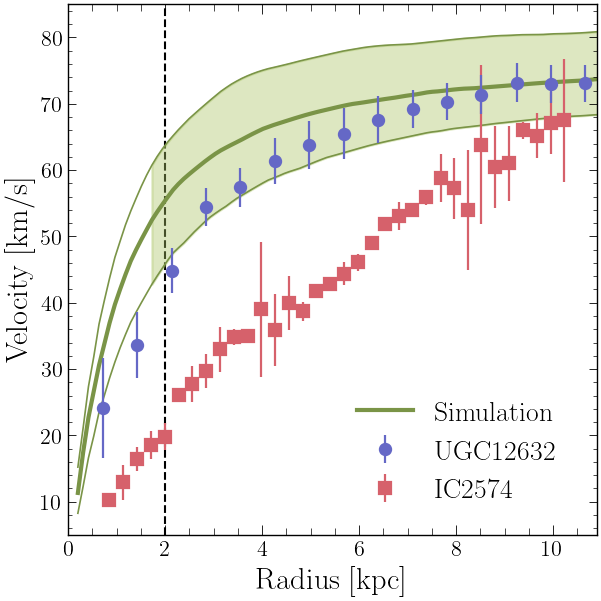

In [65]:
filter_g = [g for g in observed_galaxies if g.eta_rot > 0 and not np.isnan(g.eta_rot) and g.v_max < 80 and g.v_max > 60 and len(g.v_obs_profile) > 14]
filter_g.sort(key=lambda g: abs(g.eta_rot))
print(filter_g[0])
print(filter_g[-1])

nice_gal = filter_g[0]

fig, ax = plt.subplots(figsize=(6,6))

eagle_m_r, eagle_m_v = np.loadtxt("C:\\Home\\Astro\\TFG\\Slides\\Oman15_vcirc_eagle_median.txt",delimiter=',', unpack=True)
eagle_u_r, eagle_u_v = np.loadtxt("C:\\Home\\Astro\\TFG\\Slides\\Oman15_vcirc_eagle_up.txt",delimiter=',', unpack=True)
eagle_d_r, eagle_d_v = np.loadtxt("C:\\Home\\Astro\\TFG\\Slides\\Oman15_vcirc_eagle_down.txt",delimiter=',', unpack=True)

idx_m = np.argsort(eagle_m_r)
idx_u = np.argsort(eagle_u_r)
idx_d = np.argsort(eagle_d_r)

true_r = np.linspace(0.2,11,100)
eagle_m_v = np.interp(true_r,eagle_m_r[idx_m],eagle_m_v[idx_m])
eagle_u_v = np.interp(true_r,eagle_u_r[idx_u],eagle_u_v[idx_u])
eagle_d_v = np.interp(true_r,eagle_d_r[idx_d],eagle_d_v[idx_d])

conv_r = 1.772
first_r = np.argmin(np.abs(true_r-conv_r))
ax.fill_between(true_r[first_r:], eagle_u_v[first_r:], eagle_d_v[first_r:], color="#abc565", alpha=0.4, zorder = -5)
l1, = ax.plot(true_r, eagle_m_v, "-", color="#7a9447", lw=3, zorder = -1, label = "Simulation")
ax.plot(true_r, eagle_u_v, "-", color="#7a9447", lw=1.2, zorder = -1)
ax.plot(true_r, eagle_d_v, "-", color="#7a9447", lw=1.2, zorder = -1)

ax.set_ylabel(r"Velocity [km/s]", fontsize=22)
ax.set_xlabel(r"Radius [kpc]", fontsize=22)
ax.tick_params(labelsize=16)
ax.set_ylim(5,85)
ax.set_xlim(0,10.9)


l2 = ax.errorbar(nice_gal.rad_profile,nice_gal.v_obs_profile,yerr=nice_gal.e_v_obs_profile,color="#d6616b",marker="s",markersize=8,linestyle="None", label=nice_gal.name)
nice_gal = [g for g in filter_g if g.rad_profile[-1] > nice_gal.rad_profile[-1]*0.7 and g.rad_profile[-1] < nice_gal.rad_profile[-1]*1.5][-1]
l3 = ax.errorbar(nice_gal.rad_profile,nice_gal.v_obs_profile,yerr=nice_gal.e_v_obs_profile,color="#6568c6",marker="o",markersize=8,linestyle="None", label=nice_gal.name)

ax.axvline(2,linestyle="--",linewidth=1.5,color="k",zorder=-10)

ax.legend(handles=[l1,l3,l2], fontsize=20, loc="upper left", framealpha=1, ncols = 1, frameon = False, fancybox = False, bbox_to_anchor=(0.5, 0.3))

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable                

def plot_sim_circ(k, idx, ax, filtered_obs = None, put_legend = False):
    sim = g4[idx]
    sim_data = full_v_data[idx]
    s = sim.snap[0]
    
    # Load sigma_phi dynamically since it wasn't appended to full_v_data
    meta_v, plot_data_v, _, _ = load_npz_data(
        rf"C:\Home\Astro\TFG\Figures\Circ_models\Circ_thermal_cilinder_half\Circ_{sim.name}.npz"
    )
    r_gas = sim_data["r"]

    r1 = s.v.r1_cgas.to_value()
    vmax = np.nanmax(sim_data["v_circ"])
    r_fid = vmax / 35.0
    sim_max_r = np.nanmax(sim_data["r"])

    error = {}
    for corr in ["v_corr_p", "v_corr_d", "v_corr_a", "v_corr_t"]:
        error[corr] = np.nanmean(np.abs(sim_data[corr] - sim_data['v_circ']) / sim_data['v_circ'])
    best_corr = min(error, key=error.get)
    print(f"Best correction for {sim.name}: {best_corr} with error {error[best_corr]:.2f}")

    # --- Plot Simulation Kinematics ---
    l1, = ax.plot(r_gas, sim_data["v_circ"], color="k", linewidth=4, label=r"$V_{\rm circ}$")
    l2, = ax.plot(r_gas, sim_data["v_phi"], color="#8ca252", linewidth=2, label=r"$V_{\phi}$")
    l3, = ax.plot(r_gas, sim_data["sigma_r"], color="#8ca252", linewidth=2, linestyle="--", label=r"$\sigma_{\rm r}$")
    l4, = ax.plot(r_gas, sim_data[best_corr], color="#ad494a", linewidth=2, label=r"$V_{\rm corr}$")
    
    # Add vertical dashed lines with nice distinct colors
    vl1 = ax.axvline(r1, color='k', linestyle='--', linewidth=1, alpha=0.8, label=r"$R_{1,\rm HI}$", zorder= -4)
    vl2 = ax.axvline(r_fid, color='k', linestyle=':', linewidth=1, alpha=0.8, label=r"$R_{\rm fid}$", zorder= -4)

    # --- Plot Observations ---
    # Filter by radius similarity: Obs max radius must be within [0.4x, 2.5x] of Sim max radius
    valid_obs =[]
    for g in observed_galaxies:
        if np.isnan(g.v_max) or len(g.rad_profile) < 8:
            continue
        obs_max_r = np.nanmax(g.rad_profile)
        if 0.7 * sim_max_r <= obs_max_r <= 1.1 * sim_max_r:
            valid_obs.append(g)
            
    # Find the 2 closest observational galaxies by v_max from the filtered list
    valid_obs.sort(key=lambda g: abs(g.v_max - vmax))
    valid_obs = [obs for obs in valid_obs if obs not in filtered_obs] if filtered_obs is not None else valid_obs
    obs_closest = valid_obs[:2]

    obs_colors = ["#1f77b4", "#ff7f0e"] # Standard blue/orange
    obs_lines = []
    for j, obs in enumerate(obs_closest):
        err = ax.errorbar(
            obs.rad_profile, obs.v_obs_profile, yerr=obs.e_v_obs_profile,
            fmt='D', markersize=6, color=obs_colors[j], alpha=0.4, zorder = -2,
            label=fr"{obs.name.upper()}"
        )
        obs_lines.append(err)

    # --- Formatting & Decorations ---
    sim_name_clean = sim.name.split('-')[-1]
    label_map = {"v_corr_p": "Pressure", "v_corr_d": "Dispersion", "v_corr_a": "Anisotropy", "v_corr_t": "Thermal"}
    ax.set_title(fr"{sim_name_clean}"+r"$-$"+rf"$\langle | \Delta V_{{\rm {label_map[best_corr]}}} | / V_{{\rm circ}} \rangle = {error[best_corr]:.2f}$", fontsize=20, pad = 14)
    ax.set_xlabel(r"Radius [kpc]", fontsize=24)
    ax.tick_params(labelsize=16)
    ax.set_ylim(0,50)

    #etarot = np.interp(r_fid,sim_data["r"],sim_data["v_circ"])/vmax
    #ax.text(0.95, 0.95, rf"$\langle | \Delta V_{{\rm {label_map[best_corr]}}} | / V_{{\rm circ}} \rangle = {error[best_corr]:.2f}$", transform=ax.transAxes, fontsize=16, va='top', ha='right')
    
    # 1. Observational legend on every axis (Upper Left)
    fs_leg = 15
    obs_leg = ax.legend(handles=obs_lines, fontsize=fs_leg, loc="upper left", framealpha=1, ncols = 2, frameon = True, fancybox=True)
    ax.add_artist(obs_leg)
    
    #rad_label = [r"$R_{\rm 1, HI}$", r"$R_{\rm fid}$"]
    #for rv, rl, rp in zip([r1, r_fid], rad_label, [0.9, 0.9]):
        #+f" = {rv:.2f} kpc"
        #ax.annotate(rl, xy=(rv, rp), xycoords=('data', 'axes fraction'), xytext=(5,0), textcoords='offset points', rotation=-90, va='top', fontsize=13, zorder = -4)

    leg_fs = 18
    if put_legend:
        divider = make_axes_locatable(ax)
        sf_leg = divider.append_axes("right", size="20%", pad=0.1)
        sf_leg.axis("off")
        sf_leg.legend(handles=[l1,l4,l2,l3,vl1,vl2], fontsize=leg_fs, loc="upper left", framealpha=1, ncols = 1, frameon = False, fancybox=False)

    return obs_closest

# 3. Populate subplots
fig, axes = plt.subplots(1, 3, figsize=(6.5*2.4, 6), sharey=False, layout="constrained", width_ratios=[1,1,1.2])

# 1. Target the specific galaxies (explicitly avoiding the AGORA variant of 1e10q)
target_names =[
    #"GADGET4-CDwarf-halo291", 
    "GADGET4-CDwarf-halo307", 
    #"GADGET4-CDwarf-halo324", 
    #"GADGET4-CDwarf-halo224"
    "GADGET4-CDwarf-halo211", 
    "GADGET4-CDwarf-1e10q",
    
]
indices =[next(i for i, sim in enumerate(g4) if sim.name == name) for name in target_names]



filtered_obs = []
for k, (idx, ax) in enumerate(zip(indices, axes)):
    extra_param = {"put_legend": True} if k == len(axes)-1 else {}
    filtered_obs.extend(plot_sim_circ(k, idx, ax, filtered_obs, **extra_param))
    
    # Only label Y-axis on the leftmost plot
    if k == 0:
        ax.set_ylabel(r"Velocity [km/s]", fontsize=22)

fig.savefig(r"C:\Home\Astro\TFG\Figures\Draft\Velocity_Profiles_Comparison_only_3.png", dpi=300)


In [4]:
# Basic calcs

# GADGET4
names = ["agora_1e10q","agora_1e10v","halo185","halo196","halo211","halo224","halo234","halo256","halo273","halo291","halo307","halo316","halo324"]
for i, sim in enumerate(g4):
    log.info(f"-- Processing simulation: {sim.name} --")

    if i == 0:
        pathTab = r"C:\Home\Astro\TFG\Data\AGORA\G4\fof_subhalo_tab_336.hdf5"
    else:
        pathTab  = rf"C:\Home\Astro\TFG\Data\kazuki\fof\{names[i-1]}\fof_subhalo_tab_275.hdf5"

    s = sim.snap[0]  # snapshot view
    s.d.most_bound_pos(force_recompute=False, path = pathTab, idx = 0, label = "most_bound_pos", auto_save=False) # Halo center from most bound particle position
    s.d.center_max(force_recompute=False, radius = 5, see = False, auto_save=False, label = "center_max") # Max density position within 5 Mpc
    s.d.total_in_sphere(force_recompute=False, auto_save=False, center = s.v.most_bound_pos, radius = 1, field = ("all","particle_ones"), label = "particle_count_1kpc") # Particle count within 1 kpc of most bound position

    if s.v.particle_count_1kpc < 2000:
        log.warning(f"- Only {s.v.particle_count_1kpc} particles in 1 kpc sphere around most bound position for simulation {sim.name}. Using max density as initial proxy instead of most bound.")
        s.d.center_com_it(force_recompute=False, center = s.v.center_max, bounds = [0.005, 0.0003], iterations = 10, see = False, com_kwargs={"use_gas":True,"use_particles":True}, auto_save=False, label = "center")
    else:
        s.d.center_com_it(force_recompute=False, center = s.v.most_bound_pos, bounds = [0.005, 0.0003], iterations = 10, see = False, com_kwargs={"use_gas":True,"use_particles":True}, auto_save=False, label = "center")

    calc_core_prop(s)
    calc_kinematic_prop(s)

    sim.flush()  # Ensure all derived properties are saved to disk

# DM-only GADGET4
for i, sim in enumerate(g4_dm):
    log.info(f"-- Processing G4 DM-only simulation: {sim.name} --")
    s = sim.snap[0]  # snapshot view
    s.d.center_com_it(force_recompute=False, center = g4[i].snap[0].v.center, bounds = [4, 0.0003], iterations = 20, see = False, com_kwargs={"use_gas":False,"use_particles":True,"particle_type":"PartType1"}, auto_save=False, label = "center")

    calc_core_prop(s, altsim=g4[i].snap[0])
    calc_kinematic_prop(s, altsim=g4[i].snap[0])

    sim.flush()  # Ensure all derived properties are saved to disk

# AREPO-T
for i, sim in enumerate(arepo):
    log.info(f"-- Processing AREPO simulation: {sim.name} --")
    s = sim.snap[0]  # snapshot view

    s.d.center_max(force_recompute=False, radius = 2.5, see = False, auto_save=False, label = "center_max") # Max density position within 5 Mpc
    if i == 0:
        s.d.center_com_it(force_recompute=False, center = s.v.center_max, bounds = [0.5, 0.0003], iterations = 20, see = False, com_kwargs={"use_gas":True,"use_particles":True}, auto_save=False, label = "center")
    else:
        s.d.center_com_it(force_recompute=False, center = arepo[0].snap[0].v.center, bounds = [0.5, 0.0003], iterations = 6, see = False, com_kwargs={"use_gas":True,"use_particles":True}, auto_save=False, label = "center")

    calc_core_prop(s)
    calc_kinematic_prop(s)

    sim.flush()  # Ensure all derived properties are saved to disk

# DM-only AREPO-T
log.info(f"-- Processing AREPO DM-only simulation: {arepo_dm.name} --")
arepo_dm.snap[0].d.center_com_it(force_recompute=False, center = arepo[0].snap[0].v.center, bounds = [5, 0.0003], iterations = 16, see = False, com_kwargs={"use_gas":False,"use_particles":True,"particle_type":"PartType1"}, auto_save=True, label = "center")
calc_core_prop(arepo_dm.snap[0], altsim=arepo[0].snap[0])
calc_kinematic_prop(arepo_dm.snap[0], altsim=arepo[0].snap[0])


Dwarfs Kinematics : [INFO] 2026-05-04 15:43:17,516 -- Processing simulation: GADGET4-AGORA-1e10q --
Astroflow : [INFO] 2026-05-04 15:43:17,519 Using cached value for 'most_bound_pos' [dfe856aa] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,521 Using cached value for 'center_max' [d5bde4c2] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,524 Using cached value for 'total_in_sphere' [26310b39] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,526 Using cached value for 'center_com_it' [bc61ccd1] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,528 Using cached value for 'virial_radius_crit' [80772b79] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,530 Using cached value for 'virial_radius_mean' [80772b79] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,532 Using cached value for 'virial_radius_BN' [80772b79] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:43:17,534 Using cached value for 'radius_e_dm' [80772b79] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:

KeyboardInterrupt: 

In [5]:
s = g4[7].snap[0]

s.d.edgeon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=False)

Astroflow : [INFO] 2026-05-27 17:53:51,974 Calculating edge-on axis for snapshot 0 limited by sphere of radius 7.563582415375354 kpc using weighted angular momentum with weight HI_mass
Astroflow : [INFO] 2026-05-27 17:53:51,975 Using cached value for 'faceon_weighted' [e613d792] at snapshot 0


[0.0, -0.9996071962007813, -0.028025939834601877]

In [6]:


for i, sim in enumerate(g4):
    log.info(f"-- Processing simulation: {sim.name} --")

    s = sim.snap[0] # snapshot view
    s.d.R_den(force_recompute=False, center=s.v.center, particle="PartType0", radius=100, density_thresh=1e0, bins=40, axis=s.v.faceon, label="r1_cgas", auto_save=False, mass_field="HI_mass")
    s.d.R_den(force_recompute=False, center=s.v.center, particle="PartType0", radius=100, density_thresh=1e-1, bins=40, axis=s.v.faceon, label="r01_cgas", auto_save=False, mass_field="HI_mass")
    s.d.R_den(force_recompute=False, center=s.v.center, particle="PartType4", radius=100, density_thresh=1e0, bins=40, axis=s.v.faceon, label="r1_star", auto_save=False, mass_field="Masses")

    sim.flush() 

Dwarfs Kinematics : [INFO] 2026-05-04 15:46:40,625 -- Processing simulation: GADGET4-AGORA-1e10q --
Astroflow : [INFO] 2026-05-04 15:46:40,629 Using cached value for 'R_den' [40674404] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:46:40,631 Using cached value for 'R_den' [75af8c52] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:46:40,634 Using cached value for 'R_den' [49aad864] at snapshot 0
Dwarfs Kinematics : [INFO] 2026-05-04 15:46:40,636 -- Processing simulation: GADGET4-CDwarf-1e10q --
Astroflow : [INFO] 2026-05-04 15:46:40,638 Using cached value for 'R_den' [b45b3aa5] at snapshot 0
Astroflow : [INFO] 2026-05-04 15:46:40,641 Using cached value for 'R_den' [e2ff2ddd] at snapshot 0
Astroflow : [WARNING] 2026-05-04 15:46:40,642 Label 'r01_cgas' at snapshot 0 already points to R_den [44f3367d], but now trying to assign R_den [e2ff2ddd]. Overwriting label mapping.
Astroflow : [INFO] 2026-05-04 15:46:40,644 Using cached value for 'R_den' [03806870] at snapshot 0
Astroflow : [WARNING] 

<>:4: SyntaxWarning: invalid escape sequence '\H'
<>:4: SyntaxWarning: invalid escape sequence '\H'
C:\Users\pablo\AppData\Local\Temp\ipykernel_62644\1407858051.py:4: SyntaxWarning: invalid escape sequence '\H'
  def plot_surf_density(sims, sims_dm, faceon_fn, radius_fn = None, radius_pos = None, radius_c = None, radius_label = None, ylim = [1e-5,1e3], max_rad = 60, nbin = 80, path_prefix="C:\Home\Astro\TFG\Figures\P_alpha\Surface_Density", save = True, adaptive = True, min_particles = 75):
Dwarfs Kinematics : [INFO] 2026-04-28 16:30:42,078 -- Processing simulation: GADGET4-AGORA-1e10q --
Astroflow : [INFO] 2026-04-28 16:30:42,083 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-04-28 16:30:42,120 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Dwarfs Kinematics : [INFO] 2026-04-28 16:30:42,122 Using radius 0.259 kpc for faceon calculation in simulation GADGET4-AGORA-1e10q (using GADGET4-AGORA-1e10q for calculation)
Astroflow : [INFO] 20

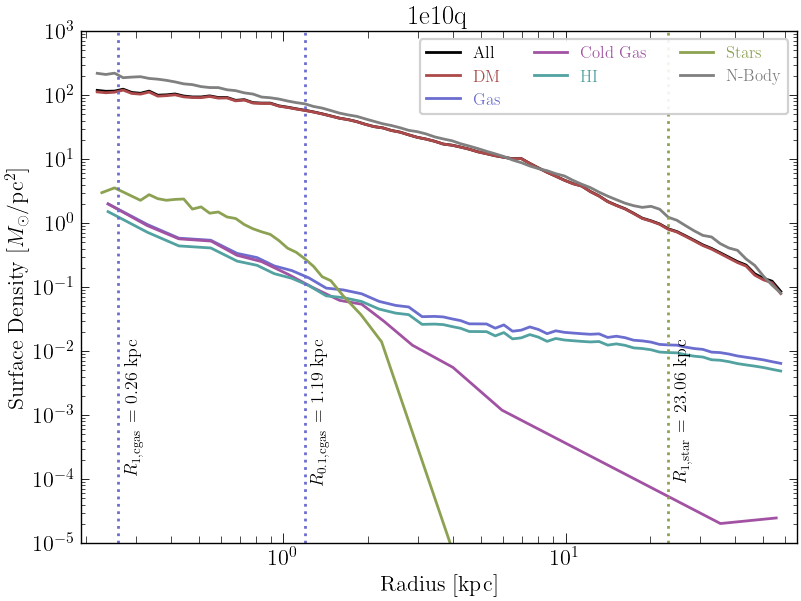

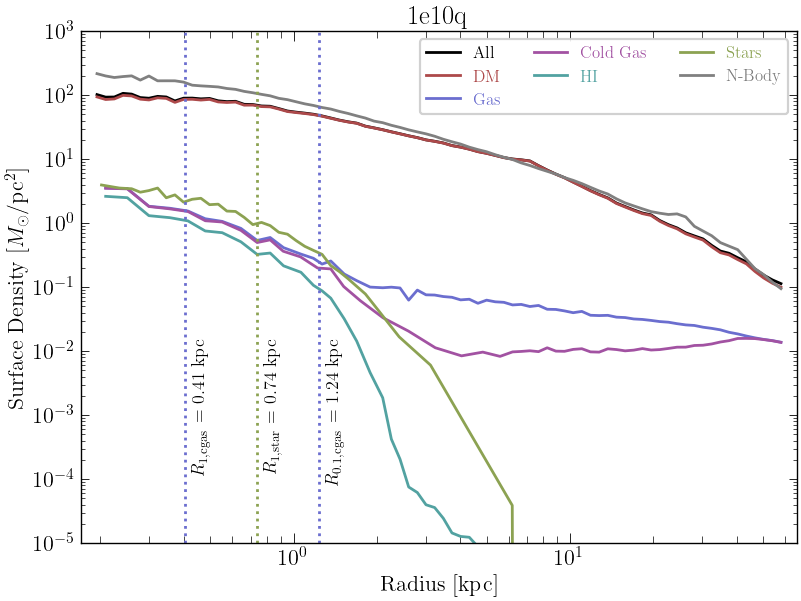

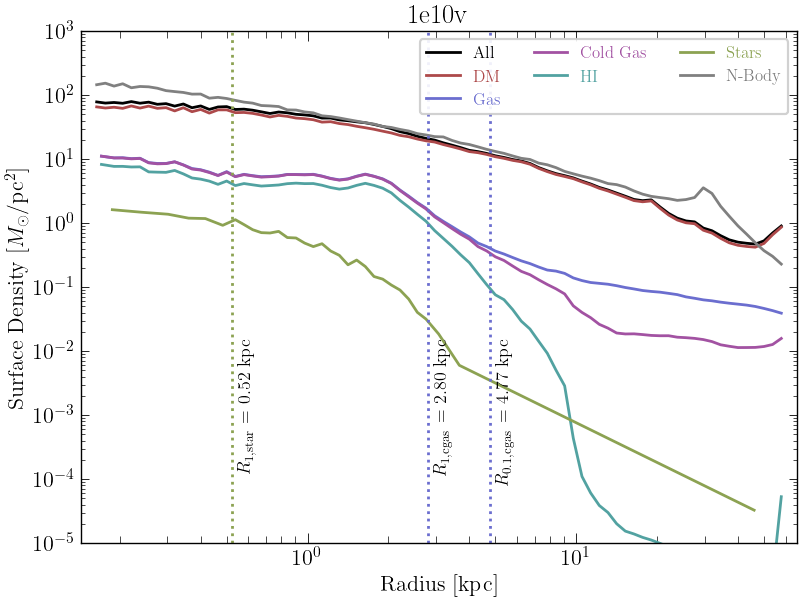

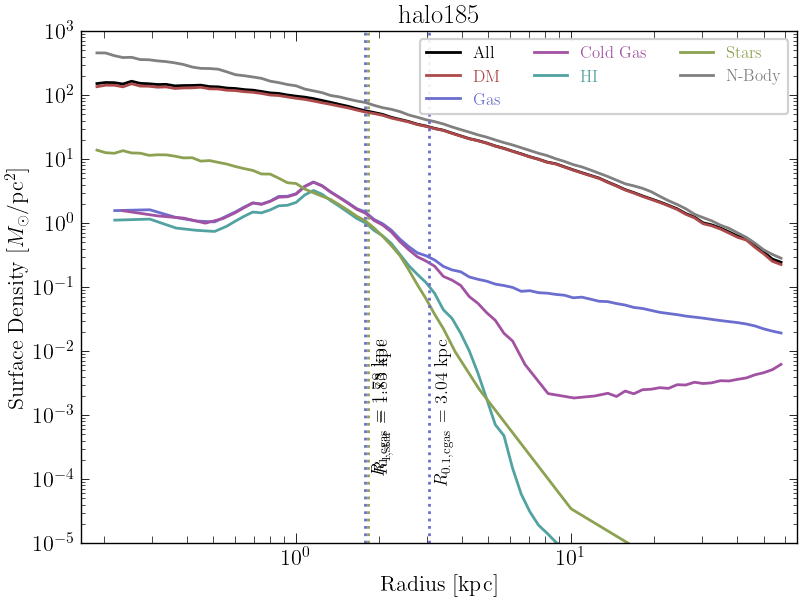

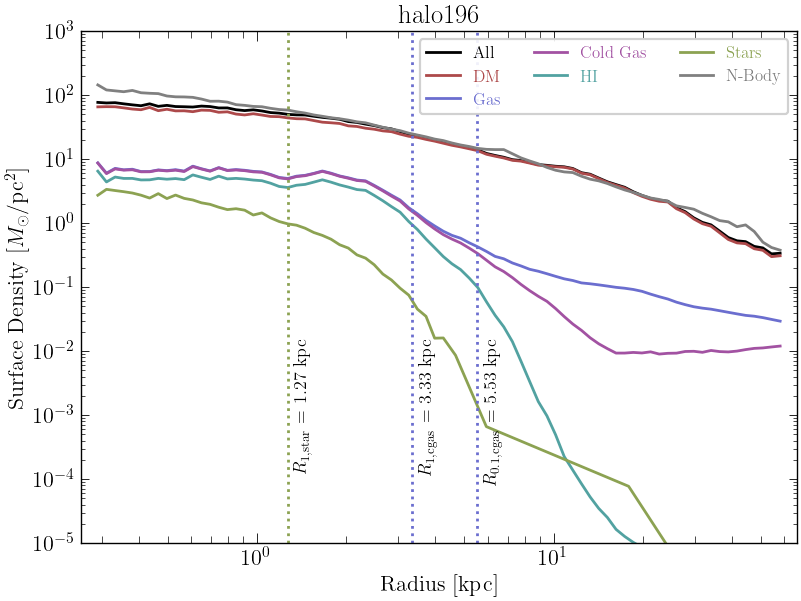

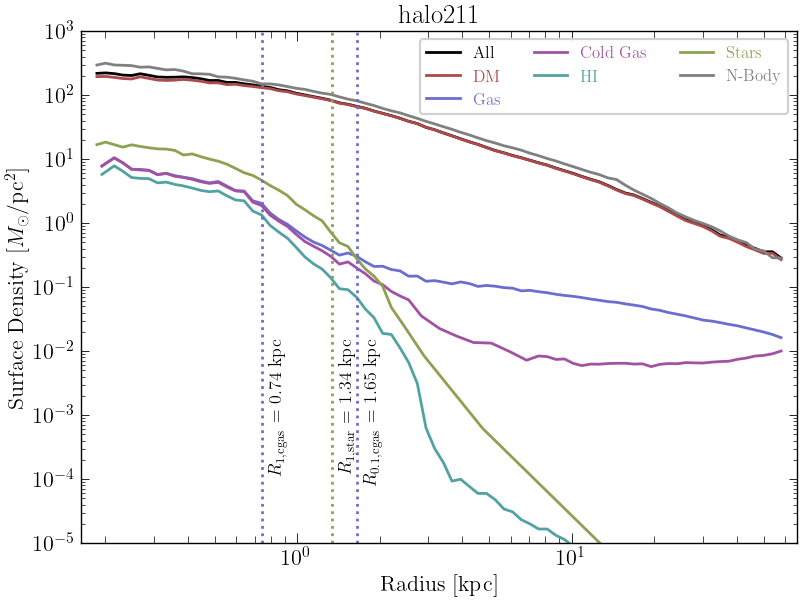

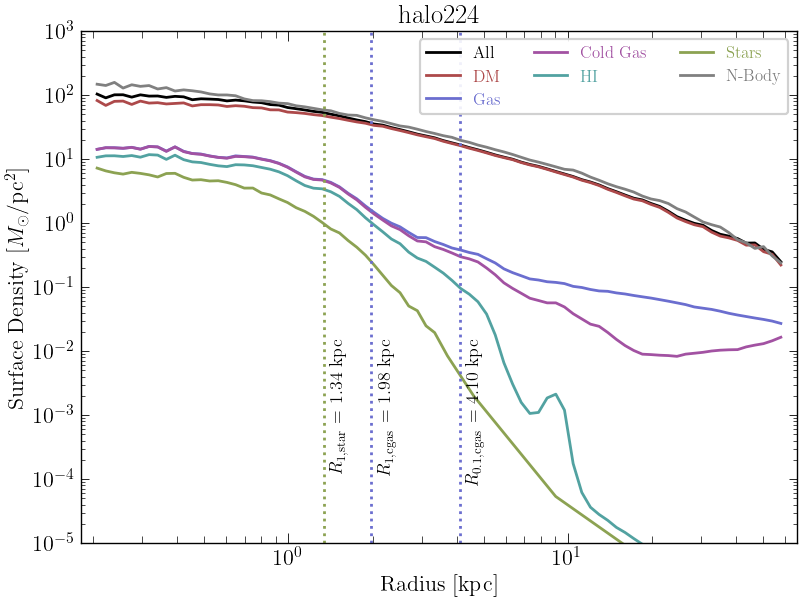

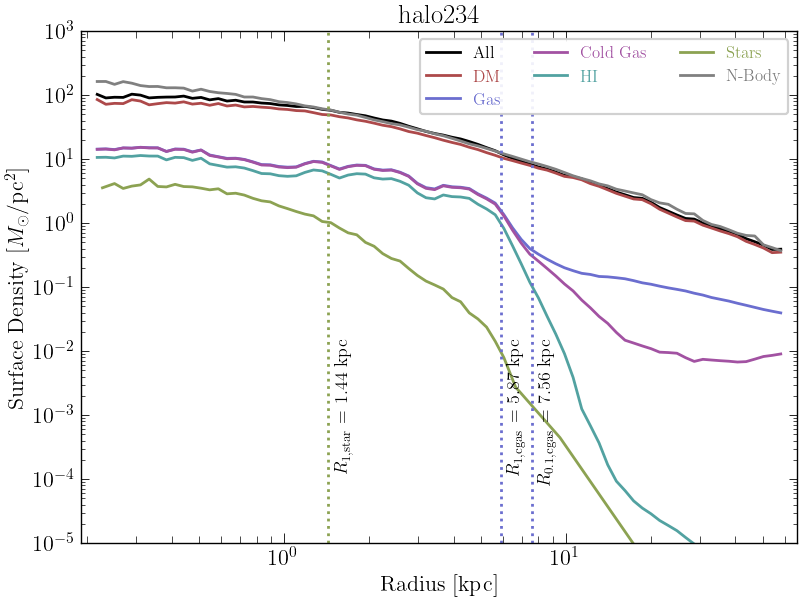

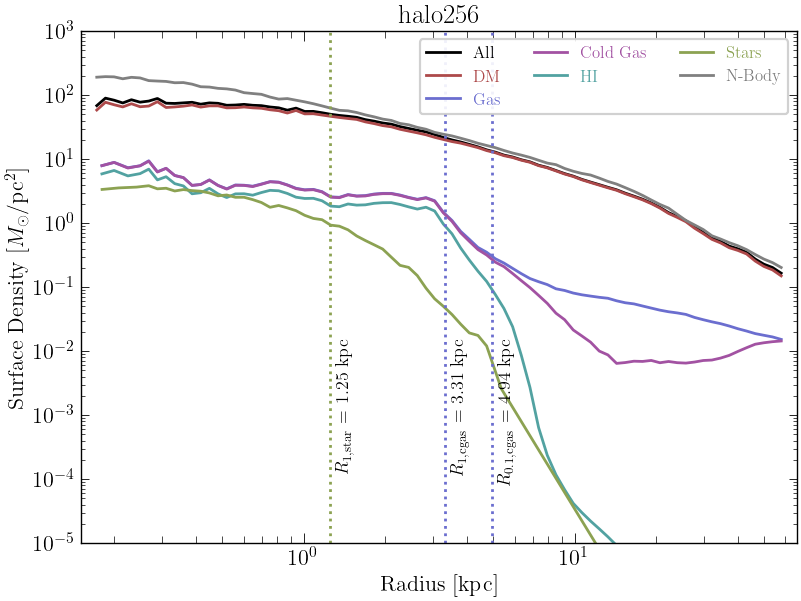

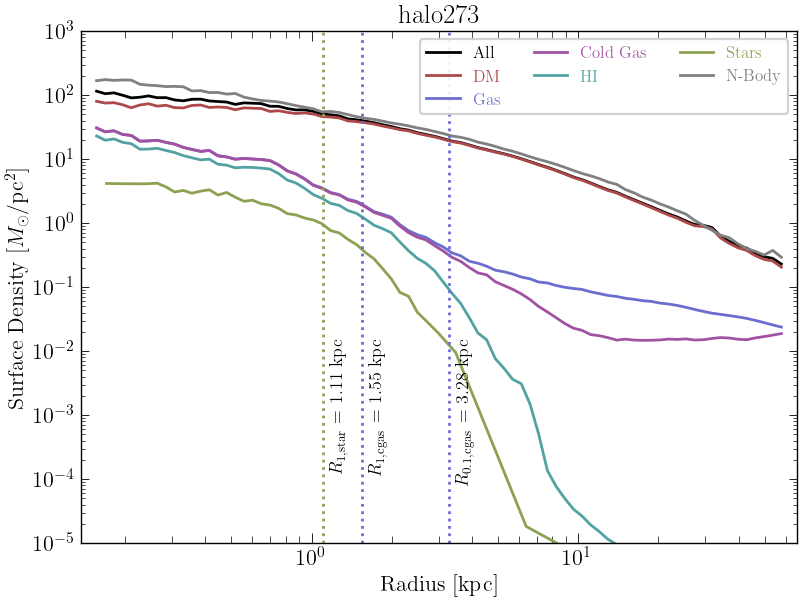

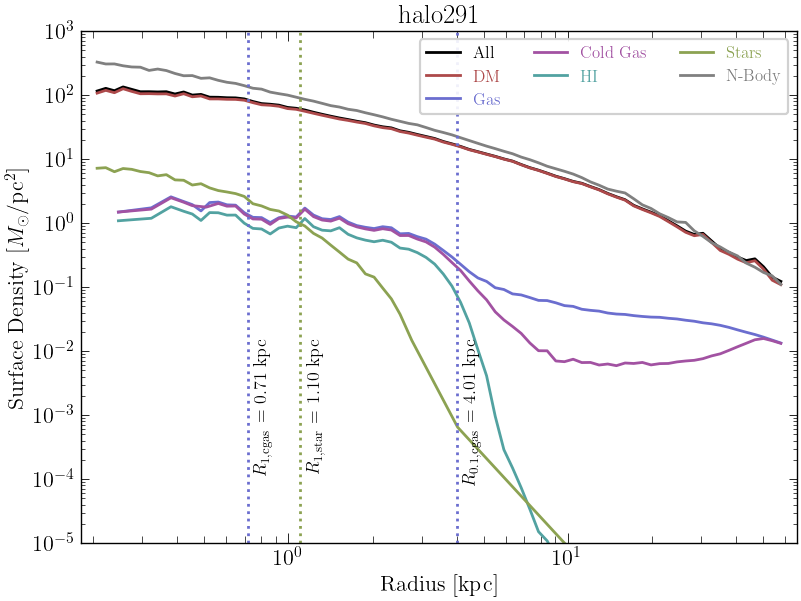

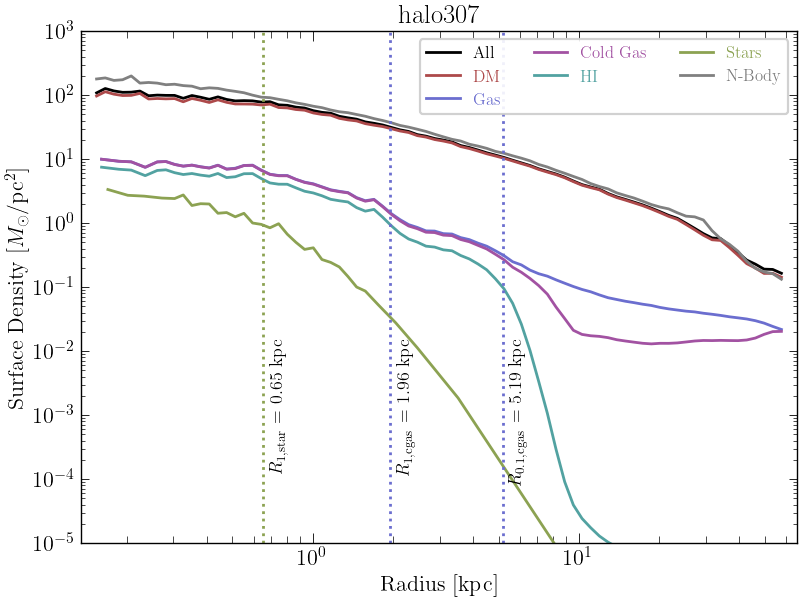

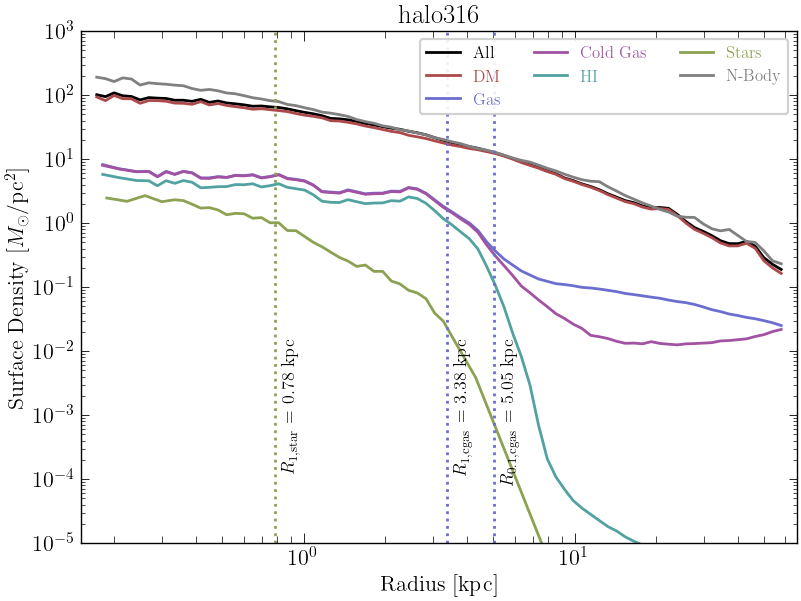

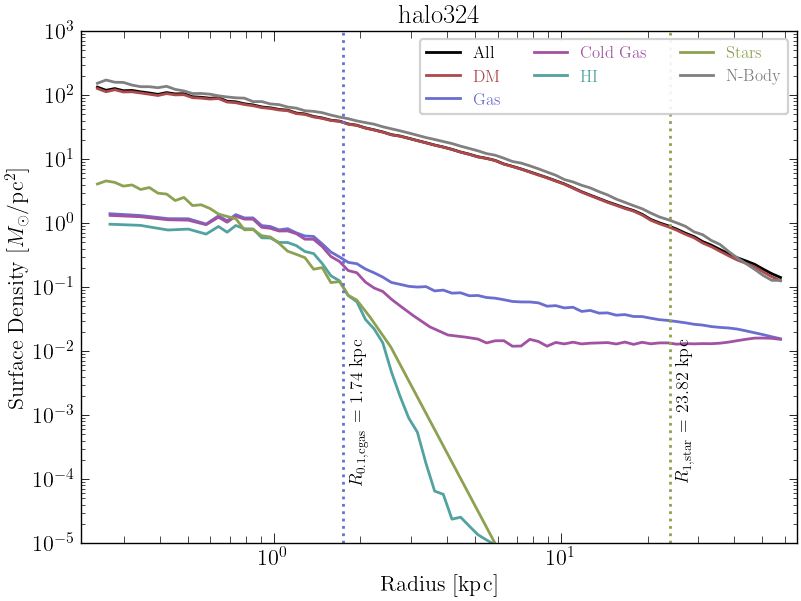

In [147]:
# Surface Density profiles


def plot_surf_density(sims, sims_dm, faceon_fn, radius_fn = None, radius_pos = None, radius_c = None, radius_label = None, ylim = [1e-5,1e3], max_rad = 60, nbin = 80, path_prefix="C:\Home\Astro\TFG\Figures\P_alpha\Surface_Density", save = True, adaptive = True, min_particles = 75):
    for i in range(len(sims)): 
        log.info(f"-- Processing simulation: {sims[i].name} --")
        s = sims[i].snap[0]
        min_rad = sims[i].get_derived("min_radius", 0, center=s.v.center, particle="all", N=1000, tol=10).to_value() # kpc

        fig, ax = plt.subplots(figsize = (8,6))
        c = ["black","#ad494a","#6b6ecf","#a252a2","#52a2a1","#8ca252"]
        sp = sims[i][0].sphere(s.v.center, (max_rad+50, "kpc"))
        sp.set_field_parameter("normal", faceon_fn(s))

        for k,fi in enumerate([("all","Masses"),("PartType1","Masses"),("PartType0","Masses"),("cold_gas","Masses"),("PartType0","HI_mass"),("PartType4","Masses")]):
            extra_kwargs = {}
            if adaptive:
                extra_kwargs = build_bins(sp, fi[0], "particle_position_cylindrical_radius", nbin, extrema=[(min_rad,max_rad)], log_x=True, min_particles=min_particles, unit="kpc")

            af.plot.profile(sp, bin_fields=(fi[0],"particle_position_cylindrical_radius"), field=fi, data_args=af.settings.DataConfig(n_bins=nbin,x_unit="kpc",unit="Msun/pc**2",  bin_extrema=[(min_rad,max_rad)], accumulate=False, postprocess="circular_surface", log = True, **extra_kwargs), style_args=af.settings.StyleConfig(ax=ax, xlog=True, ylog=True, color = c[k], linewidth = 2), io_args=af.settings.IOConfig(show=False))

        # DM sim
        s_dm = sims_dm[i].snap[0]
        sp = sims_dm[i][0].sphere(s_dm.v.center, (max_rad+50, "kpc"))
        sp.set_field_parameter("normal", faceon_fn(s_dm, altsim=s))
        af.plot.profile(sp, bin_fields=("PartType1","particle_position_cylindrical_radius"), field=("PartType1","Masses"), data_args=af.settings.DataConfig(n_bins=nbin,x_unit="kpc",unit="Msun/pc**2",  bin_extrema=[(min_rad,max_rad)], accumulate=False, postprocess="circular_surface", log = True), style_args=af.settings.StyleConfig(ax=ax, xlog=True, ylog=True, color = "gray", linewidth = 2), io_args=af.settings.IOConfig(show=False))

        if radius_fn is not None:
            if not isinstance(radius_fn, (list, tuple)):
                radius_val = [radius_fn(s)]
            else:
                radius_val = [fn(s) for fn in radius_fn]
            if radius_pos is None:
                radius_pos = [0.45]*len(radius_val)
            if radius_c is None:
                radius_c = ["black"]*len(radius_val)
            if radius_label is None:
                radius_label = [f"R={rv}" for rv in radius_val]

            for rv, rp, rl, rc in zip(radius_val, radius_pos, radius_label, radius_c):
                if rv < min_rad:
                    log.warning(f"In {s.sim.name}, radius {rv:.3f} kpc is smaller than convergence radius ({min_rad:.3f} kpc). Skipping annotation.")
                    continue
                ax.axvline(rv, color=rc, linestyle=":", linewidth=2)
                ax.annotate(rl+f" = {rv:.2f} kpc",
                    xy=(rv, rp), xycoords=('data', 'axes fraction'),
                    xytext=(5,0), textcoords='offset points',
                    rotation=90, va='top', fontsize=13)

        ax.legend(["All","DM","Gas","Cold Gas","HI","Stars","N-Body"],frameon=True,labelcolor="mfc",loc="upper right",fontsize=12,ncol=3,framealpha=0.9)
        ax.set_title(f"{sims[i].name.split('-')[-1]}")
        ax.set_ylim(ylim)
        ax.set_xlim(min_rad/1.1, max_rad*1.1)
        ax.set_xlabel("Radius [kpc]")
        ax.set_ylabel(r"Surface Density [$M_{\odot}$/pc$^2$]")
        if save:
            pathname = fr"{path_prefix}\Surface_Density_{sims[i].name}.png"
            fig.savefig(pathname, dpi=300, bbox_inches="tight")

def faceon_fn(s, altsim=None):
    sim_to_use = s if altsim is None else altsim
    minrad = sim_to_use.d.min_radius(force_recompute=False, center=sim_to_use.v.center, particle="all", N=1000, tol=10).to("kpc").to_value()
    rad_to_use = sim_to_use.v.r1_cgas.to_value()
    p_to_use = "cold_gas" if ("PartType0", "Masses") in s.ds.field_info else "PartType1"
    if rad_to_use < minrad:
        log.warning(f"In {s.sim.name} (using {sim_to_use.sim.name} for calculation), R1_cgas ({rad_to_use:.3f} kpc) is smaller than convergence radius ({minrad:.3f} kpc). Using R01_cgas instead ({sim_to_use.v.r01_cgas.to_value():.3f} kpc)")
        rad_to_use = sim_to_use.v.r01_cgas.to_value()
    log.info(f"Using radius {rad_to_use:.3f} kpc for faceon calculation in simulation {s.sim.name} (using {sim_to_use.sim.name} for calculation)")
    return s.d.faceon(force_recompute=False, radius = rad_to_use, use_particle=True, gas=False, particle=p_to_use, temp=None, center = s.v.center, auto_save=True)

plot_surf_density(g4, g4_dm, faceon_fn, radius_fn=[lambda s: s.v.r1_star.to_value(), lambda s: s.v.r1_cgas.to_value(), lambda s: s.v.r01_cgas.to_value()], radius_label=[r"$R_{\rm 1,star}$",r"$R_{\rm 1,cgas}$",r"$R_{\rm 0.1,cgas}$"], radius_pos=[0.4,0.4,0.4], radius_c=["#8ca252","#6b6ecf","#6b6ecf"], path_prefix=r"C:\Home\Astro\TFG\Figures\P_alpha\Surface_Density", save=True)

#plot_surf_density(arepo, [arepo_dm]*len(arepo), faceon_fn, radius_fn=[lambda s: s.v.r1_star.to_value(), lambda s: s.v.r1_cgas.to_value(), lambda s: s.v.r01_cgas.to_value()], radius_label=[r"$R_{\rm 1,star}$",r"$R_{\rm 1,cgas}$",r"$R_{\rm 0.1,cgas}$"], radius_pos=[0.4,0.4,0.4], radius_c=["#8ca252","#6b6ecf","#6b6ecf"], path_prefix=r"C:\Home\Astro\TFG\Figures\P_alpha\Surface_Density", save=False)


[ 7.73  8.43  7.74  8.68  8.56  9.32  9.1  10.48  9.55  8.33 11.27  9.08
  9.93  9.72  9.87  9.9   9.52  9.23  9.28 11.03  8.29  9.45  9.64  9.63
  9.78 10.86  9.43 11.27 10.88 10.05 10.68  9.97 10.62 11.03 10.65  9.
 11.3   9.28 11.03  8.86 10.53 10.68 10.64  8.41 10.22 10.58 10.57 10.13
 10.37 10.87  9.94 11.13 10.09 10.64 10.71  8.51 10.1  10.81 10.53 10.38
 10.8  10.   10.66 10.24 10.96 10.85 10.96 11.27  9.57 11.06 11.08 10.38
 11.35  9.94 11.18  7.86 10.61 11.15  9.67 10.59 10.2   9.45  9.8   9.41
  8.88  8.75  9.18 11.43 11.41 10.97 11.15 10.84 10.73 10.09  9.33  9.28
  7.69  9.35  9.79 11.03  9.12  9.24  9.01  9.5   8.41  9.22  8.71  9.77
  9.31  9.37 10.96  9.25 10.64 10.75  9.35  9.79  9.4   9.94  9.82  9.53
  9.88  9.29  8.07  9.48  9.2   9.55  8.45  7.91  8.73  8.98  8.34  9.17
  9.17  8.72 10.48  8.83 10.78 11.27  9.39 11.31  9.49 10.88 11.07  9.47
  9.76  8.62  7.98] [1.30319606 1.57054294 1.39794001 1.76715587 1.67117284 1.82930377
 1.79379038 2.25042    2.04921802 1.800

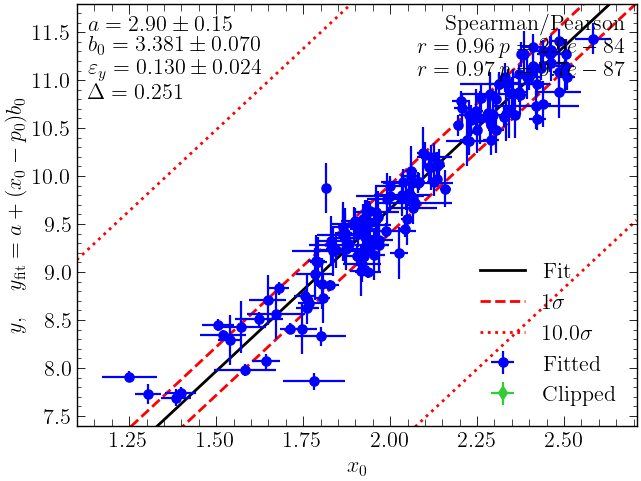

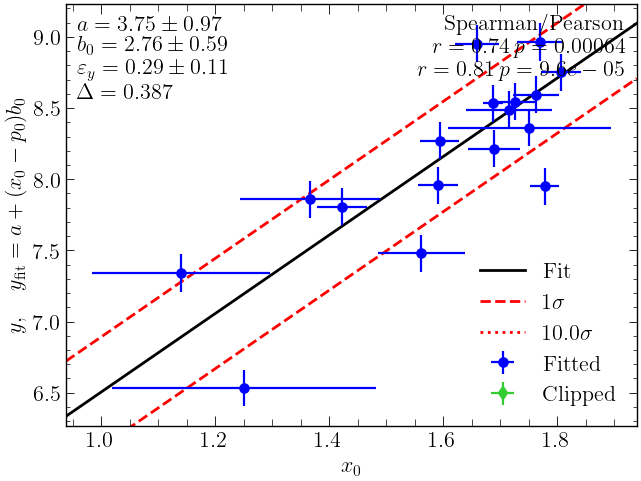

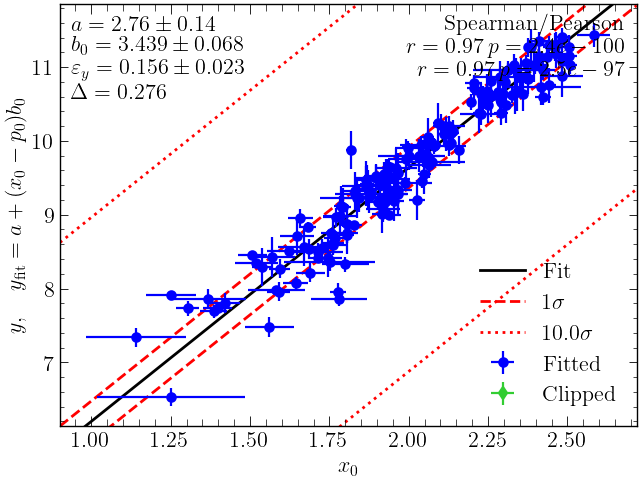

In [27]:
from ltsfit.ltsfit import ltsfit

lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500 and not np.isnan(g.m_bar)]
sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500 and not np.isnan(g.m_bar)]

def kill_nan(arr):
    mask = ~np.isnan(arr)
    return mask

def clean_btfr(vmax, mbar, e_vmax, e_mbar):
    vmax = np.array(vmax)
    mbar = np.array(mbar)
    e_vmax = np.array(e_vmax)
    e_mbar = np.array(e_mbar)
    log_vmax   = np.log10(vmax)
    log_mbar   = np.log10(mbar)
    log_e_vmax = 1/(vmax * np.log(10)) * e_vmax
    log_e_mbar = 1/(mbar * np.log(10)) * e_mbar
    mask1 = kill_nan(log_e_vmax)
    mask2 = kill_nan(log_e_mbar)
    log_e_vmax = log_e_vmax[mask1 & mask2]
    log_e_mbar = log_e_mbar[mask1 & mask2]
    log_vmax = log_vmax[mask1 & mask2]
    log_mbar = log_mbar[mask1 & mask2]
    return log_vmax, log_mbar, log_e_vmax, log_e_mbar

lt_vmax, lt_mbar, lt_e_vmax, lt_e_mbar = clean_btfr([g.v_max for g in lt_usable], [g.m_bar for g in lt_usable], [g.e_v_max for g in lt_usable], [g.e_m_bar for g in lt_usable])
sp_vmax, sp_mbar, sp_e_vmax, sp_e_mbar = clean_btfr([g.v_max for g in sparc_gals_usable], [g.m_bar for g in sparc_gals_usable], [g.e_v_max for g in sparc_gals_usable], [g.e_m_bar for g in sparc_gals_usable])

print(sp_mbar, sp_vmax, sp_e_mbar, sp_e_vmax)
print(lt_mbar, lt_vmax, lt_e_mbar, lt_e_vmax)

plt.figure()
p1 = ltsfit(sp_vmax, sp_mbar, sp_e_vmax, sp_e_mbar, clip=10, corr=True, epsy=True,
            frac=None, label='Fitted', label_clip='Clipped',
            legend=True, pivot=None, plot=True, text=True)

plt.figure()
p2 = ltsfit(lt_vmax, lt_mbar, lt_e_vmax, lt_e_mbar, clip=10, corr=True, epsy=True,
           frac=None, label='Fitted', label_clip='Clipped',
           legend=True, pivot=None, plot=True, text=True)

plt.figure()
p3 = ltsfit(
    np.concatenate([lt_vmax, sp_vmax]),
    np.concatenate([lt_mbar, sp_mbar]),
    np.concatenate([lt_e_vmax, sp_e_vmax]),
    np.concatenate([lt_e_mbar, sp_e_mbar]),
    clip=10, corr=True, epsy=True,
    frac=None, label='Fitted', label_clip='Clipped',
    legend=True, pivot=None, plot=True, text=True) #np.median(np.concatenate([lt_vmax, sp_vmax]), 0)

print(p1.sig_int, p1.sig_int_err)
print(p2.sig_int, p2.sig_int_err)
print(p3.sig_int, p3.sig_int_err)

In [176]:
from matplotlib.ticker import NullFormatter

sim_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
]
sim_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=8,
           markerfacecolor=sim_colors[i], markeredgecolor="none",
           label= (sim.name.split('-')[-1]) if i != 0 else "A-" + sim.name.split('-')[-1])
    for i, sim in enumerate(g4)
]

def make_btfr_plot(get_radius_fn, label = r"$R_{\rm 1,gas}$", xlim = (7,230), ylim = (2e6,3e11), title=None, v_max_fn = None, with_ax = None, use_arepo = False, use_Oman = False, plot_line = True, N = 0, draw_line = False, axis_fn = None, draw_colorbar = True, show_text = False, use_sim_c = True, draw_sim_legend = True, draw_rad_legend = False, alpha_obs = 0.25, lw_sim = 0, cm_str = "jet", m_size = 75, t_size = 14, fsize = 24, legend_fsize = 18):
    if not with_ax:
        #fig, ax = plt.subplots(figsize=(7,6))
        fig = plt.figure(figsize=(7.1, 5.5), constrained_layout=True)
        if use_sim_c and draw_colorbar:
            fig.set_constrained_layout_pads(wspace=0.0, w_pad=0.0)
            sf_main, sf_leg = fig.subfigures(1, 2, width_ratios=[5, 1])
            ax = sf_main.subplots()
        else:
            ax = fig.subplots()
    else:
        ax = with_ax

    norm = mcolors.LogNorm(vmin=4e-2, vmax=2e-1)
    cmap = cm.get_cmap(cm_str)
    if use_Oman:
        things_btfr_v, things_btfr_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Oman19\\BTFR_THINGS.txt",delimiter=',', unpack=True)
        lthings_btfr_v, lthings_btfr_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Oman19\\BTFR_LITTLETHINGS.txt",delimiter=',', unpack=True)
        sparc_btfr_v, sparc_btfr_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Oman19\\BTFR_SPARC.txt",delimiter=',', unpack=True)

        ax.scatter(things_btfr_v, things_btfr_m, s=120, marker = "s", label="THINGS", color="#6b6ecf")
        ax.scatter(lthings_btfr_v, lthings_btfr_m, s=120, marker = "D", label="LITTLE THINGS", color="#6b6ecf")
        ax.scatter(sparc_btfr_v, sparc_btfr_m, s=80, marker = "h", label="SPARC", color="#a252a2")
    else:
        lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500 and not np.isnan(g.m_bar) and g.e_m_bar > 0 and g.e_v_max > 0]
        sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500 and not np.isnan(g.m_bar) and g.e_m_bar > 0 and g.e_v_max > 0]
        
        ax.errorbar([g.v_max for g in lt_usable], [g.m_bar for g in lt_usable], xerr=[g.e_v_max for g in lt_usable], yerr=[g.e_m_bar for g in lt_usable], marker = "D", label="LITTLE THINGS", color="#6b6ecf", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)
        ax.errorbar([g.v_max for g in sparc_gals_usable], [g.m_bar for g in sparc_gals_usable], xerr=[g.e_v_max for g in sparc_gals_usable], yerr=[g.e_m_bar for g in sparc_gals_usable], marker = "h", label="SPARC", color="#a252a2", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)
    

    def get_mass(s, radius):
        #mgas = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = radius, particle="PartType0", auto_save=True)
        mgas = s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = radius, particle="PartType0", height = s.v.r_virial.to_value(), axis = axis_fn(s),  auto_save=True)
        #mstar = s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = radius, particle="PartType4", height = s.v.r_virial.to_value(), axis = axis_fn(s), auto_save=True)
        mstar = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = radius, particle="PartType4", auto_save=True)
        return mgas + mstar

    if v_max_fn is None:
        def v_max_fn(s, radius):
            return s.d.v_max(force_recompute=False, center = s.v.center, radius = radius, auto_save=True, particle="all", bins=50)

    if plot_line:
        true_vmax = []
        true_mass = []
        for i in range(len(g4)):
            s = g4[i].snap[0]
            baryon_fraction = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="baryon", auto_save=True)/s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="all", auto_save=True) #s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="baryon", auto_save=True)/s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r_virial.to_value(), particle="all", auto_save=True)
            min_rad = s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to_value()
            max_rad = s.v.r_virial.to_value()
            special_rad = np.array([s.v.r01_cgas.to_value(), s.v.r1_cgas.to_value()])
            masses = []
            vmaxes = []
            radii = np.sort(np.concatenate([np.linspace(min_rad, max_rad, N), special_rad]))
            for j, radius in enumerate(radii):
                masses.append(get_mass(s, radius))
                vmaxes.append(v_max_fn(s, radius))
            if draw_line:
                ax.plot(vmaxes, masses, "-", color="#ad494a")
            j = np.searchsorted(radii, special_rad)
            colors = ["#5492a3", "#58a758"]
            mk = ["s", "^"]
            true_vmax.append(np.array(vmaxes)[j])
            true_mass.append(np.array(masses)[j])
            for k, idx in enumerate(j):
                extra_args = {"label": "CROCODILE-DWARF"} if idx == j[0] and i == 0 else {"label": None}
                color = sim_colors[i] if use_sim_c else cmap(norm(baryon_fraction))
                ax.scatter(vmaxes[idx], masses[idx], s=m_size, marker = mk[k], color=color, zorder = 3, edgecolor='black', linewidth=lw_sim, **extra_args)
        
        # Obs parameters: log10(Mbar) with p3
        fit_used = p1
        i_lelli, s_lelli = fit_used.coef
        v_range = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 100)
        m_lelli = 10**(s_lelli * np.log10(v_range) + i_lelli)
        ax.plot(v_range, m_lelli, color='k', linestyle=':', alpha=1, lw=1.5, zorder=2, label='Obs Fit')
        # We use the log-space residuals to get dex scatter
        sig_sim = []
        bias_sim = []
        true_vmax = np.array(true_vmax)
        true_mass = np.array(true_mass)
        for i in range(true_vmax.shape[1]):
            print(f"Calculating residuals for radius index {i} with true_vmax {true_vmax[:, i]} and true_mass {true_mass[:, i]}")
            log_m_pred = s_lelli * np.log10(true_vmax[:-1, i]) + i_lelli
            residuals = np.log10(true_mass[:-1, i]) - log_m_pred
            bias_sim.append(np.mean(residuals))
            sig_sim.append(np.sqrt(np.mean((residuals - bias_sim[-1])**2)))
        sig_sim.append(np.sqrt(np.mean((fit_used.yy - s_lelli * fit_used.xx - i_lelli)**2)))

        # Display the info on the plot
        #text_str = f"$\\sigma_{{\\rm obs}} ={fit_used.sig_int:.2f} $ dex\n $\\sigma_{{\\rm R1}}={sig_sim[1]:.2f}$ dex\n $\\sigma_{{\\rm R0.1}}={sig_sim[0]:.2f}$ dex"
        text_str = (
        r"$\begin{aligned}"
        r"\sigma_{\rm obs} &= " + f"{sig_sim[-1]:.2f}" + r"\ \mathrm{dex} \\"
        r"\sigma_{\rm R1}  &= " + f"{sig_sim[1]:.2f}" + r"\ \mathrm{dex} \\"
        r"\langle r \rangle_{\rm R1}  &= " + f"{bias_sim[1]:.2f}" + r"\ \mathrm{dex} \\"
        r"\sigma_{\rm R0.1} &= " + f"{sig_sim[0]:.2f}" + r"\ \mathrm{dex} \\"
        r"\langle r \rangle_{\rm R0.1}  &= " + f"{bias_sim[0]:.2f}" + r"\ \mathrm{dex} "
        r"\end{aligned}$")
        ax.text(0.05, 0.72, r"$\sigma_{\rm obs} = " + f"{sig_sim[-1]:.2f}" + r"\ \mathrm{dex}$", transform=ax.transAxes, fontsize=t_size, va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        if show_text:
            text_str_sim = (
            r"$\begin{aligned}"
            r"\langle r \rangle_{\rm R1} \pm \sigma_{\rm R1}  &= " + f"{bias_sim[1]:.2f}" + r" \pm " + f"{sig_sim[1]:.2f}" + r"\ \mathrm{dex} \\"
            r"\langle r \rangle_{\rm R0.1} \pm \sigma_{\rm R0.1} &= " + f"{bias_sim[0]:.2f}" + r" \pm " + f"{sig_sim[0]:.2f}" + r"\ \mathrm{dex} "
            r"\end{aligned}$")

            ax.text(0.95, 0.05, text_str_sim, transform=ax.transAxes, fontsize=t_size, va='bottom', ha='right',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        else:
            print(text_str)

    if draw_colorbar and not use_sim_c:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label(r"Baryon Fraction $f_b$ within $R_{\rm 0.1, HI}$", fontsize=fsize)
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel("$V_{\\rm max}$ within $R$ [km/s]", fontsize=fsize) 
    ax.set_ylabel(r"LoS $M_{\rm b}$ within $R$ [$M_{\odot}$]", fontsize=fsize)
    #ax.legend(fontsize=18, labelcolor="linecolor", loc="upper left")
    gal_handles = [
    Line2D([], [], marker='D', linestyle='None', markersize=8,
           markerfacecolor='#6b6ecf', markeredgecolor='none',
           label='LITTLE THINGS'),
    Line2D([], [], marker='h', linestyle='None', markersize=8,
           markerfacecolor='#a252a2', markeredgecolor='none',
           label='SPARC'),
    Line2D([], [], marker='None', linestyle=':', markersize=8,
           color='k', markeredgecolor='none',
           label='Obs. Fit')]
    if draw_sim_legend:
        leg1 = ax.legend(handles=gal_handles, fontsize=legend_fsize, loc="upper left", handletextpad=0.25, handlelength = 1, labelcolor="mfc")
        ax.add_artist(leg1)

    rad_handles = [
        Line2D([], [], marker='s', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}$'),
        Line2D([], [], marker='^', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 1, HI}$')]
    if draw_rad_legend:
        ax.legend(handles=rad_handles, fontsize=legend_fsize, loc="lower right", handletextpad=0.25, handlelength = 1)
    if use_sim_c and draw_colorbar:
        sf_leg.legend(handles=sim_handles, fontsize=15, loc="center", frameon=False, fancybox=True, framealpha=1, edgecolor="#3B3B3B", handletextpad=0.2, labelspacing=0.92, borderpad=0.4, borderaxespad=0, handlelength = 1)
    if title:
        ax.set_title(title, fontsize=16)

def faceon_fn(s):
    return s.d.faceon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=True)

#make_btfr_plot(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=True, show_text=True, use_sim_c=False)
#make_btfr_plot(lambda s: s.v.r1_cgas.to_value(), label = r"$R_{\rm 1,cgas}$", title=r"BTFR using $R_{\rm 1,cgas}$")

C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\1827920491.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-07 18:34:30,265 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:30,268 Using cached value for 'mass_in_sphere' [9c190a7f] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:30,270 Using cached value for 'mass_in_sphere' [2cd3a891] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:30,272 Using cached value for 'mass_in_sphere' [db0ebcec] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:30,275 Using cached value for 'faceon_weighted' [86f275a9] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:30,277 Using cached value for 'mass_in_los' [978b7a05] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:30

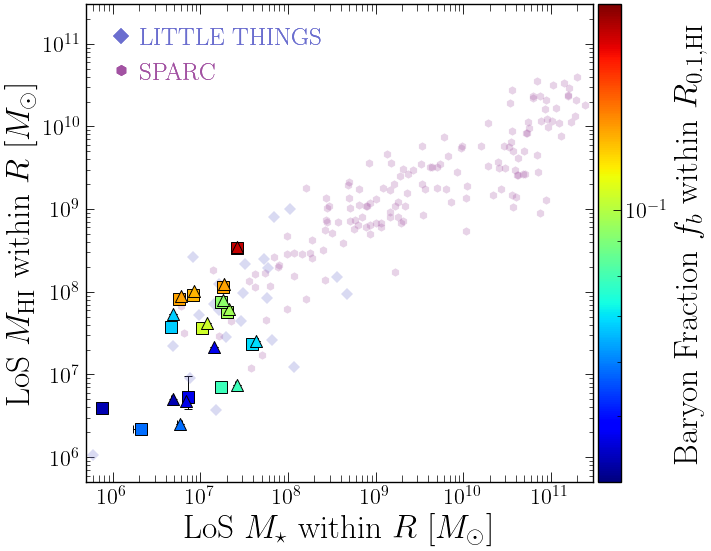

In [158]:
from matplotlib.lines import Line2D

sim_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
]
sim_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=8,
           markerfacecolor=sim_colors[i], markeredgecolor="none",
           label= (sim.name.split('-')[-1]) if i != 0 else "A-" + sim.name.split('-')[-1])
    for i, sim in enumerate(g4)
]

def make_MHI_Mstar(get_radius_fn, label = r"$R_{\rm 1,gas}$", xlim = (5e5,3e11), ylim = (5e5,3e11), title=None, with_ax = None, use_arepo = False, plot_line = True, N = 0, draw_line = False, axis_fn = None, use_sim_c = True, draw_colorbar = True, draw_sim_legend = True, draw_rad_legend = False, alpha_obs = 0.25, lw_sim = 0, cm_str = "jet", m_size = 75, fsize = 24, legend_fsize = 18, use_los_mass = True):
    if not with_ax:
        #fig, ax = plt.subplots(figsize=(7,6))
        fig = plt.figure(figsize=(7.1, 5.5), constrained_layout=True)
        if use_sim_c and draw_colorbar:
            fig.set_constrained_layout_pads(wspace=0.0, w_pad=0.0)
            sf_main, sf_leg = fig.subfigures(1, 2, width_ratios=[5, 1])
            ax = sf_main.subplots()
        else:
            ax = fig.subplots()
    else:
        ax = with_ax

    norm = mcolors.LogNorm(vmin=4e-2, vmax=2e-1)
    cmap = cm.get_cmap(cm_str)

    lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500]
    sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500]
    
    ax.errorbar([g.m_star for g in lt_usable], [g.MHI for g in lt_usable], xerr=None, yerr=None, marker = "D", label="LITTLE THINGS", color="#6b6ecf", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0) #[g.e_m_star for g in lt_usable], [g.e_m_star for g in sparc_gals_usable]
    ax.errorbar([g.m_star for g in sparc_gals_usable], [g.MHI for g in sparc_gals_usable], xerr=None, yerr=None, marker = "h", label="SPARC", color="#a252a2", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0)

    def get_m_hi(s, radius):
        #return s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = radius, particle="PartType0", mass_field="HI_mass", auto_save=True)
        return s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = radius, particle="PartType0", height = s.v.r_virial.to_value(), mass_field = "HI_mass", axis = axis_fn(s), auto_save=True)

    def get_m_star(s, radius):
        return s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = radius, particle="PartType4", auto_save=True)

    if plot_line:
        true_mhs = []
        true_mss = []
        for i in range(len(g4)):
            s = g4[i].snap[0]
            min_rad = s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to_value()
            max_rad = s.v.r_virial.to_value()
            special_rad = np.array([s.v.r01_cgas.to_value(), s.v.r1_cgas.to_value()])
            baryon_fraction = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="baryon", auto_save=True)/s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="all", auto_save=True)
            mss = []
            mhs = []
            radii = np.sort(np.concatenate([np.linspace(min_rad, max_rad, N), special_rad]))
            for j, radius in enumerate(radii):
                mss.append(get_m_star(s, radius))
                mhs.append(get_m_hi(s, radius))
            if draw_line:
                ax.plot(mss, mhs, "-", color="#ad494a")
            j = np.searchsorted(radii, special_rad)
            colors = ["#6bc5cf", "#cf6bb9"]
            mk = ["s", "^"]
            true_mss.append(np.array(mss)[j])
            true_mhs.append(np.array(mhs)[j])
            for k, idx in enumerate(j):
                extra_args = {"label": "CROCODILE-DWARF"} if idx == j[0] and i == 0 else {"label": None}
                color = sim_colors[i] if use_sim_c else cmap(norm(baryon_fraction))
                if use_los_mass:
                    rad_str = "R1" if np.isclose(radii[k], s.v.r1_cgas.to_value()) else "R01"
                    all_m_hi = mass_list[i][rad_str]["HI_mass"]
                    all_m_s = mass_list[i][rad_str]["Stellar_mass"]
                    x = np.mean(all_m_s)
                    y = np.mean(all_m_hi)
                    xerr = [[x - np.min(all_m_s)], [np.max(all_m_s) - x]]
                    yerr = [[y - np.min(all_m_hi)], [np.max(all_m_hi) - y]]
                    ax.errorbar(x, y, xerr=xerr, yerr=yerr, capsize = 3, marker = None, color="k", zorder = 2, linewidth=lw_sim, capthick = lw_sim)
                    ax.scatter(x, y, s=m_size, marker = mk[k], color=color, zorder = 3, edgecolors="black", linewidth=lw_sim, **extra_args)
                else:
                    ax.scatter(mss[idx], mhs[idx], s=m_size, marker = mk[k], color=color, zorder = 3, edgecolor='black', linewidth=lw_sim, **extra_args)
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"LoS $M_{\star}$ within $R$ [$M_{\odot}$]", fontsize=fsize) 
    ax.set_ylabel(r"LoS $M_{\rm HI}$ within $R$ [$M_{\odot}$]", fontsize=fsize)
    gal_handles = [
    Line2D([], [], marker='D', linestyle='None', markersize=8,
           markerfacecolor='#6b6ecf', markeredgecolor='none',
           label='LITTLE THINGS'),
    Line2D([], [], marker='h', linestyle='None', markersize=8,
           markerfacecolor='#a252a2', markeredgecolor='none',
           label='SPARC')]
    if draw_sim_legend:
        leg1 = ax.legend(handles=gal_handles, fontsize=legend_fsize, loc="upper left", handletextpad=0.25, handlelength = 1, labelcolor="mfc")
        ax.add_artist(leg1)

    rad_handles = [
        Line2D([], [], marker='s', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}$'),
        Line2D([], [], marker='^', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 1, HI}$')]
    if draw_rad_legend:
        ax.legend(handles=rad_handles, fontsize=legend_fsize, loc="lower right", handletextpad=0.25, handlelength = 1)
    if use_sim_c and draw_colorbar:
        sf_leg.legend(handles=sim_handles, fontsize=15, loc="center", frameon=False, fancybox=True, framealpha=1, edgecolor="#3B3B3B", handletextpad=0.2, labelspacing=0.92, borderpad=0.4, borderaxespad=0, handlelength = 1)

    if draw_colorbar and not use_sim_c:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label(r"Baryon Fraction $f_b$ within $R_{\rm 0.1, HI}$", fontsize=fsize)
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

    if title:
        ax.set_title(title, fontsize=16)

def faceon_fn(s):
    return s.d.faceon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=True)

make_MHI_Mstar(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=True, use_sim_c=False, lw_sim = 0.7)
#make_btfr_plot(lambda s: s.v.r1_cgas.to_value(), label = r"$R_{\rm 1,cgas}$", title=r"BTFR using $R_{\rm 1,cgas}$")


[ 0.08278537  0.54282543  1.02897771  0.9609462   1.24723655  0.98136551
  0.46982202  1.74593316  0.8344207   0.86391738  1.20790353  1.15775889
  1.3900515   1.20924685  1.19451434  0.8920946   1.03382569  1.50691073
  0.462398    0.86272753  1.01029996  1.2137833   1.10687054  1.69469293
  0.96378783  1.65311599  1.25911584  1.52283531  1.48415742  0.372912
  1.17926446  1.13956427  1.65436909  1.13861843  0.85491302  1.60573589
  0.48287358  1.63928723  0.77815125  1.55218134  1.27531135  1.34635297
  0.62324929  1.35353156  1.05956342  1.31889771  1.14860265  1.13735411
  1.24004977  1.00216606  1.5152113   1.24526584  1.49623755  1.17983893
  0.50242712  1.00689371  1.34733002  1.25671775  1.26904571  1.3818368
  1.20601588  1.22271647  0.83314711  1.32551566  1.01745073  1.47026345
  1.54481191  1.47755533  1.03822264  1.5965971   1.33102217  1.61161711
  1.14767632  1.69914369 -0.01322827  1.32735893  1.43152458  0.86628734
  1.08457628  0.63245729  1.49512788  1.00130093  1.22

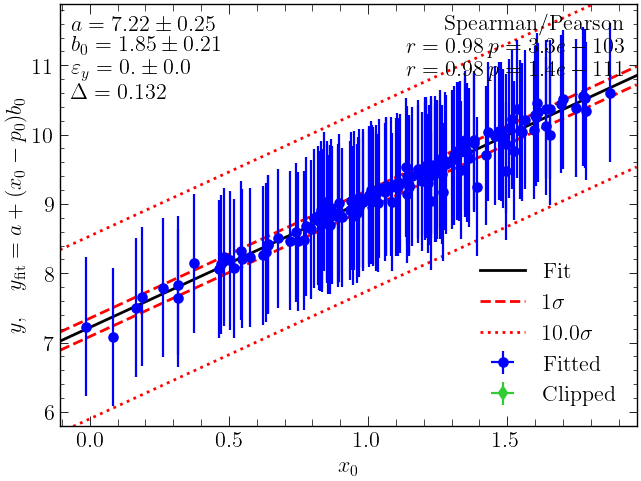

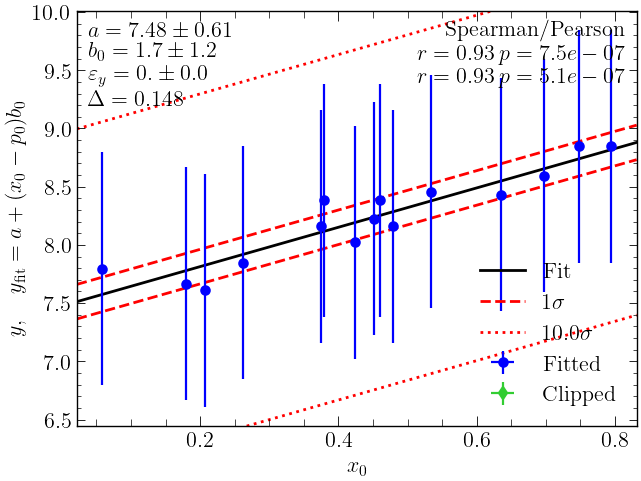

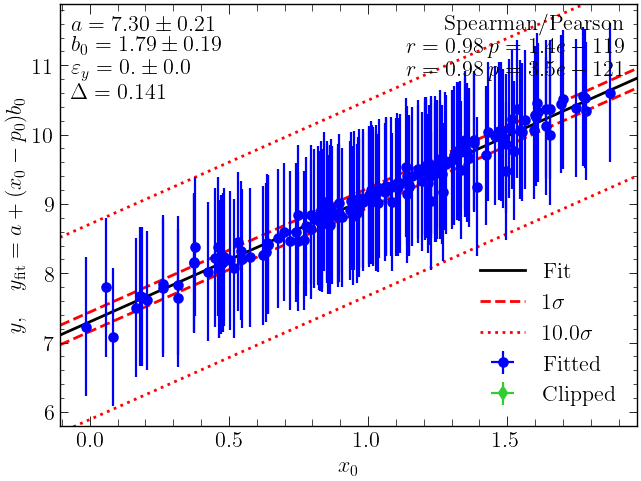

In [22]:
from ltsfit.ltsfit import ltsfit

sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500 and not np.isnan(g.MHI) and not np.isnan(g.RHI)]

def kill_nan(arr):
    mask = ~np.isnan(arr)
    return mask

def clean_mrhi(rhi, mhi):
    rhi = np.array(rhi)
    mhi = np.array(mhi)
    log_rhi = np.log10(rhi)
    log_mhi = np.log10(mhi)
    return log_rhi, log_mhi, np.zeros_like(log_rhi), np.ones_like(log_mhi)


lt_rhi, lt_mhi, lt_e_rhi, lt_e_mhi = clean_mrhi(*np.loadtxt("C:\\Home\\Astro\\TFG\\Data\\Observations\\LITTLE_THINGS_Oman19_MHIRHI.txt",delimiter=',', unpack=True))
sp_rhi, sp_mhi, sp_e_rhi, sp_e_mhi = clean_mrhi([g.RHI for g in sparc_gals_usable], [g.MHI for g in sparc_gals_usable])

print(sp_rhi, sp_mhi, sp_e_rhi, sp_e_mhi)
print(lt_rhi, lt_mhi, lt_e_rhi, lt_e_mhi)

plt.figure()
p1_rmhi = ltsfit(sp_rhi, sp_mhi, sp_e_rhi, sp_e_mhi, clip=10, corr=True, epsy=True,
            label='Fitted', label_clip='Clipped', frac = 1.0,
            legend=True, pivot=None, plot=True, text=True)

plt.figure()
p2_rmhi = ltsfit(lt_rhi, lt_mhi, lt_e_rhi, lt_e_mhi, clip=10, corr=True, epsy=True,
           label='Fitted', label_clip='Clipped', frac = 1.0,
           legend=True, pivot=None, plot=True, text=True)

plt.figure()
p3_rmhi = ltsfit(
    np.concatenate([lt_rhi, sp_rhi]),
    np.concatenate([lt_mhi, sp_mhi]),
    np.concatenate([lt_e_rhi, sp_e_rhi]),
    np.concatenate([lt_e_mhi, sp_e_mhi]),
    clip=10, corr=True, epsy=True, frac = 1.0,
    label='Fitted', label_clip='Clipped',
    legend=True, pivot=None, plot=True, text=True) #np.median(np.concatenate([lt_vmax, sp_vmax]), 0)

print(p1_rmhi.sig_int, p1_rmhi.sig_int_err)
print(p2_rmhi.sig_int, p2_rmhi.sig_int_err)
print(p3_rmhi.sig_int, p3_rmhi.sig_int_err)

C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\3865628316.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-07 18:36:21,322 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:36:21,324 Using cached value for 'mass_in_sphere' [9c190a7f] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:36:21,327 Using cached value for 'mass_in_sphere' [2cd3a891] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:36:21,329 Using cached value for 'faceon_weighted' [86f275a9] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:36:21,332 Using cached value for 'mass_in_los' [978b7a05] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:36:21,341 Using cached value for 'min_radius' [e6e690c4] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:36:21,343

R 0 [0.25928869 0.40579793 2.79762751 1.77868361 3.33432706 0.74461885
 1.98128741 5.87427193 3.31267545 1.54939871 0.71420793 1.95958433
 3.38231943 0.        ] [3.78170591e+06 2.06172816e+06 8.02265157e+07 2.22395281e+07
 1.13144003e+08 6.82562675e+06 5.62612583e+07 3.32315540e+08
 7.33117638e+07 3.68178971e+07 3.87475707e+06 3.48806539e+07
 9.26381761e+07 6.05996703e+05]


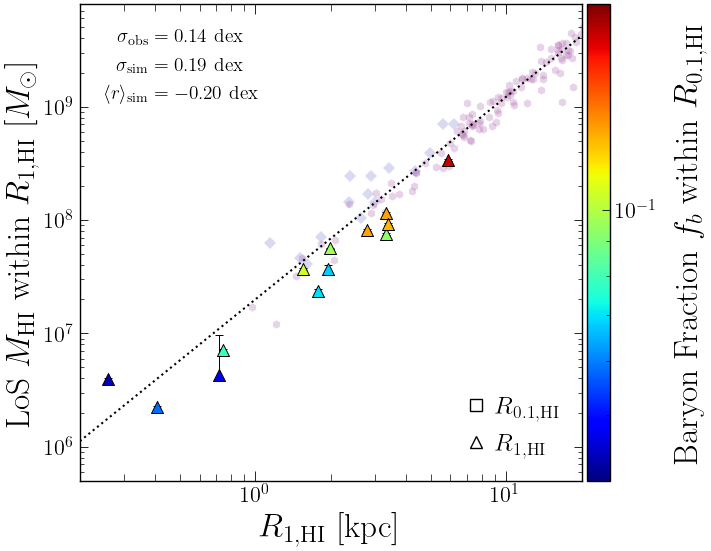

In [164]:

                
sim_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
]
sim_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=8,
           markerfacecolor=sim_colors[i], markeredgecolor="none",
           label= (sim.name.split('-')[-1]) if i != 0 else "A-" + sim.name.split('-')[-1])
    for i, sim in enumerate(g4)
]

def make_MHI_RHI(get_radius_fn, label = r"$R_{\rm 1,gas}$", xlim = (2e-1,2e1), ylim = (5e5,8e9), title=None, with_ax = None, use_arepo = False, plot_line = True, N = 0, draw_line = False, axis_fn = None, use_sim_c = True, draw_colorbar = True, show_text = True, draw_sim_legend = True, draw_rad_legend = False, alpha_obs = 0.25, lw_sim = 0, cm_str = "jet", m_size = 75, fsize = 24, legend_fsize = 18, t_fsize = 14, use_los_mass = True):
    if not with_ax:
        #fig, ax = plt.subplots(figsize=(7,6))
        fig = plt.figure(figsize=(7.1, 5.5), constrained_layout=True)
        if use_sim_c and draw_colorbar:
            fig.set_constrained_layout_pads(wspace=0.0, w_pad=0.0)
            sf_main, sf_leg = fig.subfigures(1, 2, width_ratios=[5, 1])
            ax = sf_main.subplots()
        else:
            ax = fig.subplots()
    else:
        ax = with_ax
        fig = with_ax.get_figure()
        if use_sim_c and draw_colorbar:
            divider = make_axes_locatable(ax)
            sf_leg = divider.append_axes("right", size="20%", pad=0.1)
            sf_leg.axis("off")

    norm = mcolors.LogNorm(vmin=4e-2, vmax=2e-1)
    cmap = cm.get_cmap(cm_str)

    #lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500]
    sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500]
    lt_rhi, lt_mhi = np.loadtxt("C:\\Home\\Astro\\TFG\\Data\\Observations\\LITTLE_THINGS_Oman19_MHIRHI.txt",delimiter=',', unpack=True)
    #ax.errorbar([g.RHI for g in lt_usable], [g.MHI for g in lt_usable], xerr=None, yerr=None, marker = "D", label="LITTLE THINGS", color="#6b6ecf", linestyle="None", elinewidth=1, alpha = 0.6, markeredgewidth=0)
    ax.errorbar(lt_rhi, lt_mhi, xerr=None, yerr=None, marker = "D", label="LITTLE THINGS", color="#6b6ecf", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)
    ax.errorbar([g.RHI for g in sparc_gals_usable], [g.MHI for g in sparc_gals_usable], xerr=None, yerr=None, marker = "h", label="SPARC", color="#a252a2", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)

    def get_m_hi(s, radius):
        return s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = radius, particle="PartType0", height = s.v.r_virial.to_value(), axis = axis_fn(s), mass_field = "HI_mass", auto_save=True)
        #return s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="PartType0", mass_field="HI_mass", auto_save=True)

    def get_r_hi(s, radius):
        return radius


    if plot_line:
        true_mhs = []
        true_rhs = []
        for i in range(len(g4)):
            s = g4[i].snap[0]
            min_rad = s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to_value()
            max_rad = s.v.r_virial.to_value()
            special_rad = np.array([s.v.r1_cgas.to_value()])
            baryon_fraction = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="baryon", auto_save=True)/s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="all", auto_save=True)
            rhs = []
            mhs = []
            radii = np.sort(np.concatenate([np.linspace(min_rad, max_rad, N), special_rad]))
            for j, radius in enumerate(radii):
                rhs.append(get_r_hi(s, radius))
                mhs.append(get_m_hi(s, get_radius_fn(s)))
            if draw_line:
                ax.plot(rhs, mhs, "-", color="#ad494a")
            j = np.searchsorted(radii, special_rad)
            colors = ["#6bc5cf", "#cf6bb9"]
            mk = ["^", "s"]
            true_rhs.append(np.array(rhs)[j])
            true_mhs.append(np.array(mhs)[j])
            for k, idx in enumerate(j):
                extra_args = {"label": "CROCODILE-DWARF"} if idx == j[0] and i == 0 else {"label": None}
                color = sim_colors[i] if use_sim_c else cmap(norm(baryon_fraction))

                if use_los_mass:
                    rad_str = "R1" if np.isclose(rhs[idx], s.v.r1_cgas.to_value()) else "R01"
                    all_m = mass_list[i][rad_str]["HI_mass"]
                    
                    y = np.mean(all_m)
                    yerr = [[y - np.min(all_m)], [np.max(all_m) - y]]
                    ax.errorbar(rhs[idx], y, yerr=yerr, capsize = 3, marker = None, color="k", zorder = 2, linewidth=lw_sim, capthick = lw_sim)
                    ax.scatter(rhs[idx], np.median(all_m), s=m_size, marker = mk[k], color=color, zorder = 3, edgecolors="black", linewidth=lw_sim, **extra_args)
                else:
                    ax.scatter(rhs[idx], mhs[idx], s=m_size, marker = mk[k], color=color, zorder = 3, edgecolors="black", linewidth=lw_sim, **extra_args)

        # Obs parameters
        fit_used = p3_rmhi
        log_a, log_m = fit_used.coef
        r_range = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 100)
        m_obs = 10**(log_m * np.log10(r_range) + log_a)
        ax.plot(r_range, m_obs, color='k', linestyle=':', alpha=1, lw=1.5, zorder=2, label='Obs Fit')
        # We use the log-space residuals to get dex scatter
        sig_sim = []
        bias_sim = []
        true_rhs = np.array(true_rhs)
        true_mhs = np.array(true_mhs)
        for i in range(true_rhs.shape[1]):
            print("R",i,true_rhs[:,i], true_mhs[:,i])
            log_m_pred = log_m * np.log10(true_rhs[:-1, i]) + log_a
            residuals = np.log10(true_mhs[:-1, i]) - log_m_pred
            #sig_sim.append(np.sqrt(np.mean(residuals**2)))
            bias_sim.append(np.mean(residuals))
            sig_sim.append(np.sqrt(np.mean((residuals - bias_sim[-1])**2)))
        sig_sim.append(np.sqrt(np.mean((fit_used.yy - log_m * fit_used.xx - log_a)**2)))
        
        # Display the info on the plot
        text_str = (
        r"$\begin{aligned}"
        r"\sigma_{\rm obs} &= " + f"{sig_sim[-1]:.2f}" + r"\ \mathrm{dex} \\"
        r"\sigma_{\rm sim}  &= " + f"{sig_sim[0]:.2f}" + r"\ \mathrm{dex} \\"
        r"\langle r \rangle_{\rm sim}  &= " + f"{bias_sim[0]:.2f}" + r"\ \mathrm{dex} \\"
        r"\end{aligned}$")
        if show_text:
            y_text = 0.65 if draw_sim_legend else 0.95 
            ax.text(0.05, y_text, text_str, transform=ax.transAxes, fontsize=t_fsize, va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))
        else:
            print(text_str)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"$R_{\rm 1,HI}$ [kpc]", fontsize=fsize) 
    ax.set_ylabel(r"LoS $M_{\rm HI}$ within $R_{\rm 1,HI}$ [$M_{\odot}$]", fontsize=fsize)
    gal_handles = [
    Line2D([], [], marker='D', linestyle='None', markersize=8,
           markerfacecolor='#6b6ecf', markeredgecolor='none',
           label='LITTLE THINGS'),
    Line2D([], [], marker='h', linestyle='None', markersize=8,
           markerfacecolor='#a252a2', markeredgecolor='none',
           label='SPARC'),
    Line2D([], [], marker='None', linestyle=':', markersize=8,
           color='k', markeredgecolor='none',
           label='Obs. Fit')]
    if draw_sim_legend:
        leg1 = ax.legend(handles=gal_handles, fontsize=legend_fsize, loc="upper left", handletextpad=0.25, handlelength = 1, labelcolor="mfc")
        ax.add_artist(leg1)

    rad_handles = [
        Line2D([], [], marker='s', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}$'),
        Line2D([], [], marker='^', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 1, HI}$')]
    if draw_rad_legend:
        ax.legend(handles=rad_handles, fontsize=legend_fsize, loc="lower right", handletextpad=0.25, handlelength = 1)

    if draw_colorbar and not use_sim_c:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label(r"Baryon Fraction $f_b$ within $R_{\rm 0.1, HI}$", fontsize=fsize, labelpad = 12.0)
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

    if use_sim_c and draw_colorbar:
        sf_leg.legend(handles=sim_handles, fontsize=15, loc="center", frameon=False, fancybox=True, framealpha=1, edgecolor="#3B3B3B", handletextpad=0.2, labelspacing=0.92, borderpad=0.4, borderaxespad=0, handlelength = 1)
    if title:
        ax.set_title(title, fontsize=16)

def faceon_fn(s):
    return s.d.faceon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=True)

#s.v.r01_cgas.to_value()
make_MHI_RHI(lambda s: s.v.r1_cgas.to_value(), label = r"$R$", title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=True, show_text=True, use_sim_c=False, draw_sim_legend=False, draw_rad_legend=True, lw_sim = 0.7)


In [134]:
print([s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to("pc").to_value() for s in [g.snap[0] for g in g4]])

print([s.v.v_max.to("km/s").to_value()/35 for s in [g.snap[0] for g in g4]])

Astroflow : [INFO] 2026-05-06 23:44:10,822 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,826 Using cached value for 'min_radius' [e6e690c4] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,830 Using cached value for 'min_radius' [1ced3fcf] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,832 Using cached value for 'min_radius' [57c5a4c2] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,834 Using cached value for 'min_radius' [17e63788] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,838 Using cached value for 'min_radius' [597219c4] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,840 Using cached value for 'min_radius' [bf2bc7dc] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,843 Using cached value for 'min_radius' [1808afa6] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,846 Using cached value for 'min_radius' [2e72f827] at snapshot 0
Astroflow : [INFO] 2026-05-06 23:44:10,849 Using cached value fo

[210.9375, 187.5, 158.203125, 181.640625, 281.25, 179.6875, 199.21875, 209.9609375, 166.015625, 150.390625, 199.21875, 148.4375, 166.015625, 234.375]
[0.31304012375364737, 0.46160747602521135, 0.8536628556899434, 1.1356294303463357, 0.9583210136502485, 0.7604857260060179, 0.911384132479799, 1.2028001716442083, 1.018102665340249, 0.7950738904383868, 0.8098729749233236, 0.9165151625621681, 0.9468890754036897, 0.6403541867746195]


C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\1734335081.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-16 02:28:25,882 Using cached value for 'mass_in_sphere' [9c190a7f] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:25,885 Using cached value for 'mass_in_sphere' [2cd3a891] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:25,888 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:25,890 Using cached value for 'faceon_weighted' [86f275a9] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:25,891 Using cached value for 'mass_in_los' [03cc2068] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:25,893 Using cached value for 'mass_in_sphere' [db0ebcec] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:25

Calculating residuals for radius index 0 with true_vmax [24.99129031 24.80405192 31.27256654 42.0432629  35.36722921 35.36519684
 35.53399469 42.09800601 37.17647881 31.31845744 35.25621884 34.87679215
 33.65831874 28.5891381 ] and true_mass [1.08184217e+07 1.47376645e+07 1.61548005e+08 9.11184721e+07
 2.38364271e+08 4.44726213e+07 1.34359149e+08 5.54903467e+08
 1.54689440e+08 8.96194552e+07 6.10066947e+07 1.08105884e+08
 1.84661908e+08 2.12591960e+07]
Calculating residuals for radius index 1 with true_vmax [ 8.61566009 12.61911689 29.1958439  38.53251004 32.89412824 24.56956421
 30.70874786 42.09800601 35.63359329 25.2856477  21.93526201 31.3290444
 32.68869341  1.26475913] and true_mass [5.25684812e+06 8.21517736e+06 1.30856257e+08 7.36195145e+07
 1.95213640e+08 2.69992555e+07 1.07693911e+08 5.13365339e+08
 1.31695928e+08 6.85819476e+07 1.50124368e+07 6.04400971e+07
 1.57866663e+08 4.15563596e+06]
$\begin{aligned}\sigma_{\rm obs} &= 0.25\ \mathrm{dex} \\\sigma_{\rm R1}  &= 0.28\ \mat

Astroflow : [INFO] 2026-05-16 02:28:26,596 Using cached value for 'mass_in_los' [197117c6] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,607 Using cached value for 'min_radius' [bf2bc7dc] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,609 Using cached value for 'mass_in_sphere' [02b89066] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,613 Using cached value for 'mass_in_sphere' [c33101e8] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,615 Using cached value for 'mass_in_sphere' [63b517a1] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,618 Using cached value for 'faceon_weighted' [3798a0bd] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,619 Using cached value for 'mass_in_los' [bf97bda2] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,622 Using cached value for 'mass_in_sphere' [28337f21] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:26,626 Using cached value for 'faceon_weighted' [3798a0bd] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:28:

R 0 [0.25928869 0.40579793 2.79762751 1.77868361 3.33432706 0.74461885
 1.98128741 5.87427193 3.31267545 1.54939871 0.71420793 1.95958433
 3.38231943 0.        ] [3.78170591e+06 2.06172816e+06 8.02265157e+07 2.22395281e+07
 1.13144003e+08 6.82562675e+06 5.62612583e+07 3.32315540e+08
 7.33117638e+07 3.68178971e+07 3.87475707e+06 3.48806539e+07
 9.26381761e+07 6.05996703e+05]


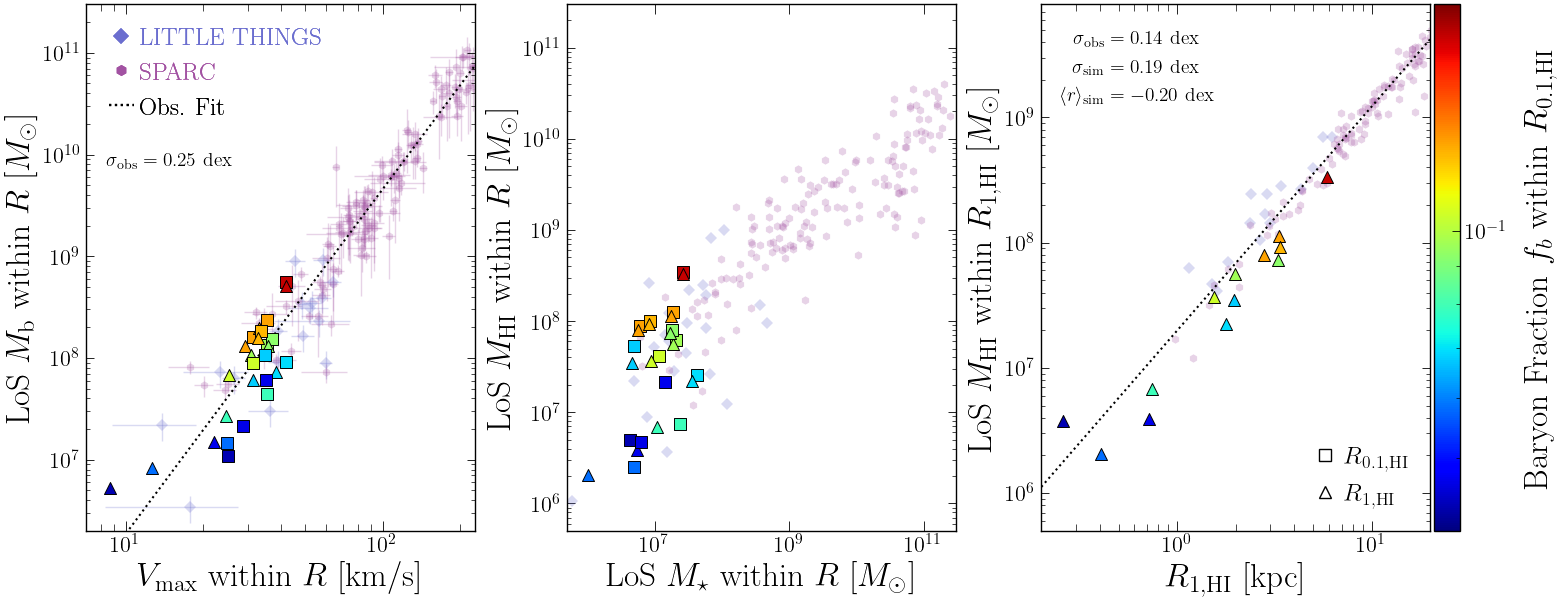

In [179]:
fig, ax = plt.subplots(1, 3, figsize=(6.5*2.4, 6), constrained_layout=True)

def faceon_fn(s):
    return s.d.faceon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=True)

make_btfr_plot(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=False, show_text=False, use_sim_c=False, with_ax=ax[0], draw_rad_legend=False, draw_sim_legend=True, lw_sim = 0.7, t_size = 14)
make_MHI_Mstar(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=False, use_sim_c=False,  with_ax=ax[1], draw_rad_legend=False, draw_sim_legend=False, lw_sim = 0.7, use_los_mass = False)
make_MHI_RHI(lambda s: s.v.r1_cgas.to_value(), label = r"$R$", title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=True, show_text=True, use_sim_c=False,  with_ax=ax[2], draw_rad_legend=True, draw_sim_legend=False, lw_sim = 0.7, use_los_mass = False, t_fsize = 14)

fig.savefig(r"C:\Home\Astro\TFG\Figures\Draft\BTFR_MHI_Mstar_RHI.png", dpi=300)



C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\199831624.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-16 02:26:47,505 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:26:47,508 Using cached value for 'mass_in_sphere' [e34ec892] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:26:47,512 Using cached value for 'mass_in_sphere' [9c95a7e2] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:26:47,519 Using cached value for 'mass_in_sphere' [94a56478] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:26:47,521 Using cached value for 'mass_in_sphere' [2b05d85e] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:26:47,527 Using cached value for 'mass_in_sphere' [5ab0624b] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:26:4

[unyt_quantity(1675686.21667037, 'Msun'), unyt_quantity(4255214.26007729, 'Msun'), unyt_quantity(7418398.70169438, 'Msun'), unyt_quantity(49809849.47766434, 'Msun'), unyt_quantity(1784590.49746449, 'Msun'), unyt_quantity(5920200.70774075, 'Msun'), unyt_quantity(9901380.27809642, 'Msun'), unyt_quantity(1.09656202e+08, 'Msun'), unyt_quantity(1991101.10773537, 'Msun'), unyt_quantity(94204454.24526133, 'Msun'), unyt_quantity(1.36463957e+08, 'Msun'), unyt_quantity(4.0325988e+08, 'Msun'), unyt_quantity(1370767.11957042, 'Msun'), unyt_quantity(57858819.54571895, 'Msun'), unyt_quantity(81845763.5084781, 'Msun'), unyt_quantity(2.69967484e+08, 'Msun'), unyt_quantity(1591371.95868494, 'Msun'), unyt_quantity(1.41773147e+08, 'Msun'), unyt_quantity(2.02562075e+08, 'Msun'), unyt_quantity(5.35996484e+08, 'Msun'), unyt_quantity(1568913.44491741, 'Msun'), unyt_quantity(22065317.3165013, 'Msun'), unyt_quantity(36010938.73164663, 'Msun'), unyt_quantity(2.18395962e+08, 'Msun'), unyt_quantity(1888157.430267

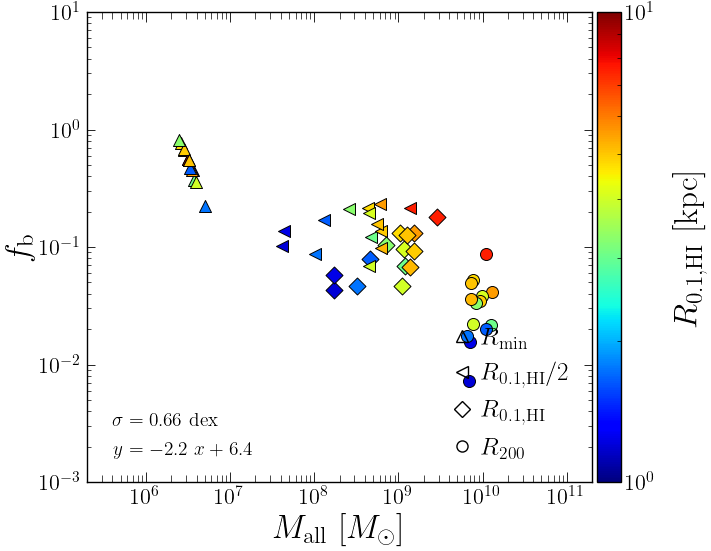

In [177]:

def make_fb(xlim = (2e5,2e11), ylim = (1e-3,1e1), title=None, with_ax = None, use_arepo = False, plot_line = True, N = 0, draw_line = False, axis_fn = None, use_sim_c = True, draw_colorbar = True, show_text = True, draw_sim_legend = True, draw_rad_legend = False, alpha_obs = 0.25, lw_sim = 0, cm_str = "jet", m_size = 75, fsize = 24, legend_fsize = 18, t_fsize = 14, use_los_mass = True):
    if not with_ax:
        #fig, ax = plt.subplots(figsize=(7,6))
        fig = plt.figure(figsize=(7.1, 5.5), constrained_layout=True)
        if use_sim_c and draw_colorbar:
            fig.set_constrained_layout_pads(wspace=0.0, w_pad=0.0)
            sf_main, sf_leg = fig.subfigures(1, 2, width_ratios=[5, 1])
            ax = sf_main.subplots()
        else:
            ax = fig.subplots()
    else:
        ax = with_ax
        fig = with_ax.get_figure()
        if use_sim_c and draw_colorbar:
            divider = make_axes_locatable(ax)
            sf_leg = divider.append_axes("right", size="20%", pad=0.1)
            sf_leg.axis("off")

    norm = mcolors.LogNorm(vmin=1e0, vmax=1e1)
    cmap = cm.get_cmap(cm_str)

    def get_m_all(s, radius):
        return s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = radius, particle="all", mass_field="Masses", auto_save=True)

    def get_m_b(s, radius):
        return s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = radius, particle="baryon", mass_field="Masses", auto_save=True)

    mk = ["^", "<", "D", "o"]   
    if plot_line:
        true_m_all = []
        true_m_b = []
        for i in range(len(g4)):
            s = g4[i].snap[0]
            min_rad = s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to_value()
            max_rad = s.v.r_virial.to_value()
            radii = np.array([min_rad, s.v.r01_cgas.to_value()/2, s.v.r01_cgas.to_value(), max_rad])
           
            for j, radius in enumerate(radii):
                m_all = get_m_all(s, radius)
                m_b = get_m_b(s, radius)
                true_m_all.append(m_all)
                true_m_b.append(m_b)

                color = sim_colors[i] if use_sim_c else cmap(norm(s.v.r01_cgas.to_value()))
                ax.scatter(m_all, m_b/m_all, s=m_size, marker = mk[j], color=color, zorder = 3, edgecolors="black", linewidth=lw_sim)
        print(true_m_b, true_m_all)
        # Linear regression
        x_fit = np.log10(np.array(true_m_b)/np.array(true_m_all))
        y_fit = np.log10(true_m_all)
        a, b = np.polyfit(x_fit, y_fit, 1)
        
        # Plot the dashed line
        x_line = np.linspace(np.min(x_fit), np.max(x_fit), 100)
        ax.plot(x_line, a * x_line + b, color='k', linestyle='--', lw=2, zorder=-10, alpha = 0.5)
        # Calculate residuals and their standard deviation
        residuals = y_fit - (a * x_fit + b)
        std_res = np.std(residuals)   

        text_str = (
        r"$\begin{aligned}"
        r"\sigma &= " + f"{std_res:.2f}" + r"\ \mathrm{dex} \\"
        r"y &= " + fr"{a:.2g}\ x + {b:.2g}"
        r"\end{aligned}$")
        if show_text:
            y_text = 0.05 
            ax.text(0.05, y_text, text_str, transform=ax.transAxes, fontsize=t_fsize, va='bottom', ha='left',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

        # Obs parameters
        #fit_used = p3_rmhi
        #log_a, log_m = fit_used.coef
        #r_range = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 100)
        #m_obs = 10**(log_m * np.log10(r_range) + log_a)
        #ax.plot(r_range, m_obs, color='k', linestyle=':', alpha=1, lw=1.5, zorder=2, label='Obs Fit')
        # We use the log-space residuals to get dex scatter
        #sig_sim = []
        #bias_sim = []
        #true_rhs = np.array(true_rhs)
        #true_mhs = np.array(true_mhs)
        #for i in range(true_rhs.shape[1]):
        #    print("R",i,true_rhs[:,i], true_mhs[:,i])
        #    log_m_pred = log_m * np.log10(true_rhs[:-1, i]) + log_a
        #    residuals = np.log10(true_mhs[:-1, i]) - log_m_pred
            #sig_sim.append(np.sqrt(np.mean(residuals**2)))
        #    bias_sim.append(np.mean(residuals))
        #    sig_sim.append(np.sqrt(np.mean((residuals - bias_sim[-1])**2)))
        #sig_sim.append(np.sqrt(np.mean((fit_used.yy - log_m * fit_used.xx - log_a)**2)))
        
        # Display the info on the plot
        #text_str = (
        #r"$\begin{aligned}"
        #r"\sigma_{\rm obs} &= " + f"{sig_sim[-1]:.2f}" + r"\ \mathrm{dex} \\"
        #r"\sigma_{\rm sim}  &= " + f"{sig_sim[0]:.2f}" + r"\ \mathrm{dex} \\"
        #r"\langle r \rangle_{\rm sim}  &= " + f"{bias_sim[0]:.2f}" + r"\ \mathrm{dex} \\"
        #r"\end{aligned}$")
        #if show_text:
        #    y_text = 0.65 if draw_sim_legend else 0.95 
        #    ax.text(0.05, y_text, text_str, transform=ax.transAxes, fontsize=t_fsize, va='top', ha='left',
        #        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"$M_{\rm all}$ [$M_{\odot}$]", fontsize=fsize) 
    ax.set_ylabel(r"$f_{\rm b}$", fontsize=fsize)

    rad_handles = [
        Line2D([], [], marker=mk[0], linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm min}$'),
        Line2D([], [], marker=mk[1], linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}/2$',),
        Line2D([], [], marker=mk[2], linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}$'),
        Line2D([], [], marker=mk[3], linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 200}$')]
    if draw_rad_legend:
        ax.legend(handles=rad_handles, fontsize=legend_fsize, loc="lower right", handletextpad=0.25, handlelength = 1)

    if draw_colorbar and not use_sim_c:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label(r"$R_{\rm 0.1, HI}$ [kpc]", fontsize=fsize, labelpad = 12.0)
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())

    if use_sim_c and draw_colorbar:
        sf_leg.legend(handles=sim_handles, fontsize=15, loc="center", frameon=False, fancybox=True, framealpha=1, edgecolor="#3B3B3B", handletextpad=0.2, labelspacing=0.92, borderpad=0.4, borderaxespad=0, handlelength = 1)
    if title:
        ax.set_title(title, fontsize=16)

#s.v.r01_cgas.to_value()
make_fb(title=None, plot_line=True, axis_fn = faceon_fn, draw_colorbar=True, show_text=True, use_sim_c=False, draw_sim_legend=False, draw_rad_legend=True, lw_sim = 0.7)

In [93]:
#s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = rad, particle="PartType0", height = s.v.r_virial.to_value(), axis = axis, auto_save=False)


thingy = list(g4[0].meta["snapshots"][0]["derived_properties"]["mass_in_los"].values())
print([thingy[i]["params"]["axis"] if "params" in thingy[i] else None for i in range(len(thingy))])


[{'unit': 'dimensionless', 'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834]}, {'unit': 'dimensionless', 'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834]}, [0, 0, 1], {'unit': 'dimensionless', 'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834]}, [1, 0, 0], {'unit': 'dimensionless', 'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834]}, None, [1, 0, 0], None, None, {'unit': 'dimensionless', 'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834]}, {'unit': 'dimensionless', 'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834]}, [1, 0, 0], {'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834], 'unit': 'dimensionless'}, {'value': [0.937217556913697, -0.079781241786732, -0.33949698742652834], 'unit': 'dimensionless'}, array([ 0.93721756, -0.07978124, -0.33949699]), array([ 0.93721756, -0.07978124, -0.33949699]), array([ 0.93721756, -0.07978124, -0.33949699]), a

In [100]:
mass_list = []

for i,sim in enumerate(g4):
    s = sim.snap[0]
    log.info(f"Processing {sim.name} for axis computation...")
    fon = np.array(s.d.faceon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=False))
    eon = np.array(s.d.edgeon_weighted(force_recompute=False, radius = s.v.r01_cgas.to_value(), particle="PartType0", weight="HI_mass", center = s.v.center, auto_save=False))

    incs = np.linspace(0, 90, 10)
    axis_list = [(np.cos(np.radians(inc)) * fon + np.sin(np.radians(inc)) * eon).tolist() for inc in incs]

    sim_dict = {"sim": sim.name, "axis_list": axis_list, "incs": incs, "R1": {"HI_mass": [], "Gas_mass": [], "Stellar_mass": []}, "R01": {"HI_mass": [], "Gas_mass": [], "Stellar_mass": []}}
    for axis in axis_list:
        for rad in [s.v.r01_cgas.to_value(), s.v.r1_cgas.to_value()]:
            log.info(f"Computing masses for {sim.name} at radius {rad} and axis {axis}...")
            rad_str = "R01" if np.abs(rad-s.v.r01_cgas.to_value()) < 1e-3 else "R1"
            if rad < 1e-3:
                log.info(f"Skipping {sim.name} with radius {rad}")
                sim_dict[rad_str]["Gas_mass"].append(0)
                sim_dict[rad_str]["HI_mass"].append(0)
                sim_dict[rad_str]["Stellar_mass"].append(0)
                continue
            sim_dict[rad_str]["Gas_mass"].append(s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = rad, particle="PartType0", height = s.v.r_virial.to_value(), axis = axis, auto_save=False))
            sim_dict[rad_str]["HI_mass"].append(s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = rad, particle="PartType0", height = s.v.r_virial.to_value(), axis = axis, mass_field = "HI_mass", auto_save=False))
            sim_dict[rad_str]["Stellar_mass"].append(s.d.mass_in_los(force_recompute=False, center = s.v.center, radius = rad, particle="PartType4", height = s.v.r_virial.to_value(), axis = axis, auto_save=False))
    mass_list.append(sim_dict)
    sim.flush()

Dwarfs Kinematics : [INFO] 2026-05-05 16:55:02,125 Processing GADGET4-AGORA-1e10q for axis computation...
Astroflow : [INFO] 2026-05-05 16:55:02,128 Using cached value for 'faceon_weighted' [86f275a9] at snapshot 0
Astroflow : [INFO] 2026-05-05 16:55:02,133 Using cached value for 'edgeon_weighted' [86f275a9] at snapshot 0
Dwarfs Kinematics : [INFO] 2026-05-05 16:55:02,136 Computing masses for GADGET4-AGORA-1e10q at radius 1.1895799562167133 and axis [0.937217556913697, -0.079781241786732, -0.33949698742652834]...
Astroflow : [INFO] 2026-05-05 16:55:02,137 Using cached value for 'mass_in_los' [329ec1c9] at snapshot 0
Astroflow : [INFO] 2026-05-05 16:55:02,140 Using cached value for 'mass_in_los' [bc38fe33] at snapshot 0
Astroflow : [INFO] 2026-05-05 16:55:02,141 Using cached value for 'mass_in_los' [717f024a] at snapshot 0
Dwarfs Kinematics : [INFO] 2026-05-05 16:55:02,142 Computing masses for GADGET4-AGORA-1e10q at radius 0.2592886884292359 and axis [0.937217556913697, -0.0797812417867

In [141]:
print(mass_list)

[{'sim': 'GADGET4-AGORA-1e10q', 'axis_list': [array([ 0.93721756, -0.07978124, -0.33949699]), array([ 0.90825047, -0.2515916 , -0.33433927]), array([ 0.85168666, -0.41575748, -0.31902281]), array([ 0.76924477, -0.56729078, -0.29401302]), array([ 0.66342978, -0.70158723, -0.26006978]), array([ 0.5374568 , -0.81456631, -0.21822446]), array([ 0.39515348, -0.9027952 , -0.16974849]), array([ 0.24084361, -0.96359312, -0.11611481]), array([ 0.07921583, -0.99511275, -0.05895303]), array([-8.48188773e-02, -9.96396386e-01, -2.07881949e-17])], 'incs': array([ 0., 10., 20., 30., 40., 50., 60., 70., 80., 90.]), 'R1': {'HI_mass': [unyt_quantity(3781705.90730483, 'Msun'), unyt_quantity(3871289.45926222, 'Msun'), unyt_quantity(3945601.48623798, 'Msun'), unyt_quantity(4003876.35717906, 'Msun'), unyt_quantity(4025349.54621292, 'Msun'), unyt_quantity(4043697.77973594, 'Msun'), unyt_quantity(4035527.05681022, 'Msun'), unyt_quantity(3960264.49280789, 'Msun'), unyt_quantity(3884059.50880115, 'Msun'), unyt_q

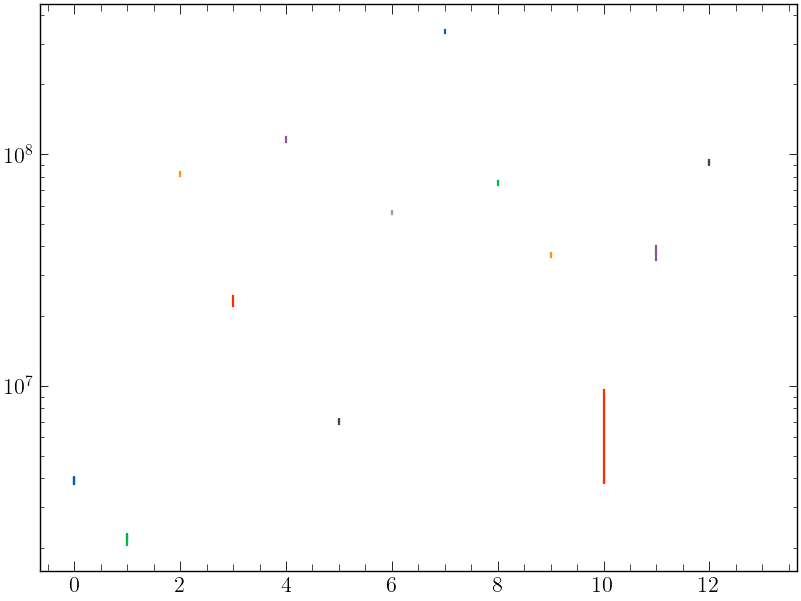

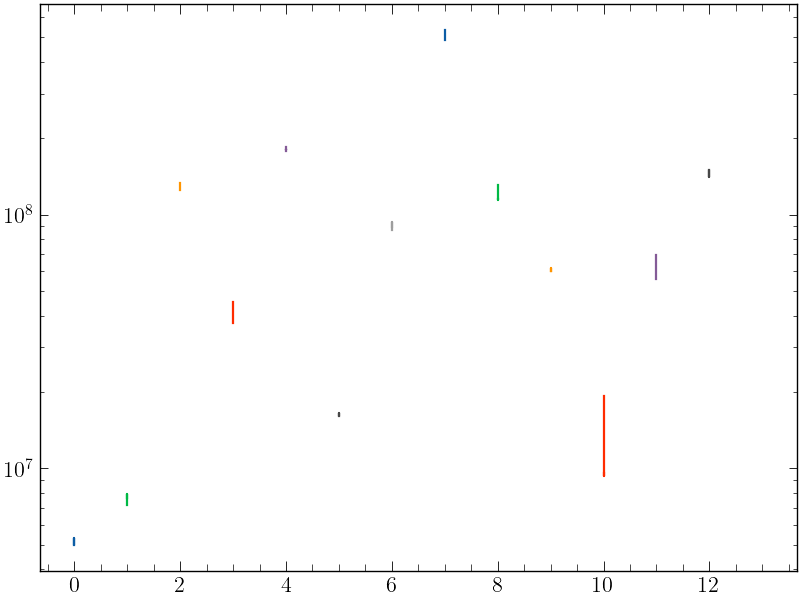

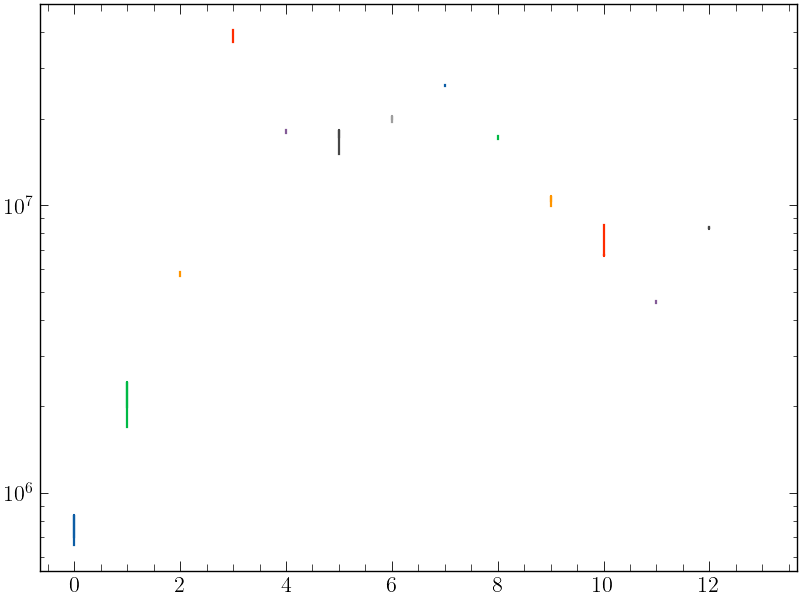

In [144]:
plt.figure(figsize=(8,6))
for i, sim_dict in enumerate(mass_list):
    plt.semilogy([i]*10, sim_dict["R1"]["HI_mass"])
plt.figure(figsize=(8,6))
for i, sim_dict in enumerate(mass_list):
    plt.semilogy([i]*10, sim_dict["R1"]["Gas_mass"])
plt.figure(figsize=(8,6))    
for i, sim_dict in enumerate(mass_list):
    plt.semilogy([i]*10, sim_dict["R1"]["Stellar_mass"])

In [3]:
g4[0][0].derived_field_list

[('PartType0', 'CELibCalcium'),
 ('PartType0', 'CELibCarbon'),
 ('PartType0', 'CELibHelium'),
 ('PartType0', 'CELibHydrogen'),
 ('PartType0', 'CELibIron'),
 ('PartType0', 'CELibMagnesium'),
 ('PartType0', 'CELibNeon'),
 ('PartType0', 'CELibNickel'),
 ('PartType0', 'CELibNitrogen'),
 ('PartType0', 'CELibOxygen'),
 ('PartType0', 'CELibSilicon'),
 ('PartType0', 'CELibSulfur'),
 ('PartType0', 'Coordinates'),
 ('PartType0', 'DI'),
 ('PartType0', 'DII'),
 ('PartType0', 'Density'),
 ('PartType0', 'ElectronAbundance'),
 ('PartType0', 'H2I'),
 ('PartType0', 'H2II'),
 ('PartType0', 'HDI'),
 ('PartType0', 'HI'),
 ('PartType0', 'HII'),
 ('PartType0', 'HI_density'),
 ('PartType0', 'HI_mass'),
 ('PartType0', 'HM'),
 ('PartType0', 'HeI'),
 ('PartType0', 'HeII'),
 ('PartType0', 'HeIII'),
 ('PartType0', 'InternalEnergy'),
 ('PartType0', 'Masses'),
 ('PartType0', 'Metallicity'),
 ('PartType0', 'ParticleIDs'),
 ('PartType0', 'Pressure'),
 ('PartType0', 'SmoothingLength'),
 ('PartType0', 'StarFormationRat

In [18]:
all_data = np.genfromtxt(r"C:\Home\Astro\TFG\Data\Observations\LITTLE_THINGS_SS20.txt", 
                         dtype=None, encoding='utf-8',
                         names=['name', 'type', 'vmax', 'vbmax', 'vfid', 'vbfid', 'mbar', 'rbhalf', 'm200'])


lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500]
lt_usable.sort(key=lambda x: x.name)
all_data = np.sort(all_data, order='name')

count = 0
for i in range(len(lt_usable)):
    for j in range(len(all_data)):
        if lt_usable[i].name.strip(' (LT)') == all_data['name'][j]:
            lt_usable[i].eta_bar = (all_data["vbfid"][j] / all_data["vfid"][j])**2
            count += 1
print(f"Total matches found: {count} out of {len(lt_usable)} usable galaxies and {len(all_data)} entries in all_data.")

Total matches found: 11 out of 26 usable galaxies and 11 entries in all_data.


C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\3382352178.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-16 02:29:34,520 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:29:34,523 Using cached value for 'v_max' [5cc4dba7] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:29:34,529 Using cached value for 'v_fid' [bedc7531] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:29:34,534 Using cached value for 'v_max' [5cc4dba7] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:29:34,537 Using cached value for 'v_fid' [bedc7531] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:29:34,539 Using cached value for 'v_fid' [a6b325cf] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:29:34,544 Using cached value for 'v_max' [3b4138

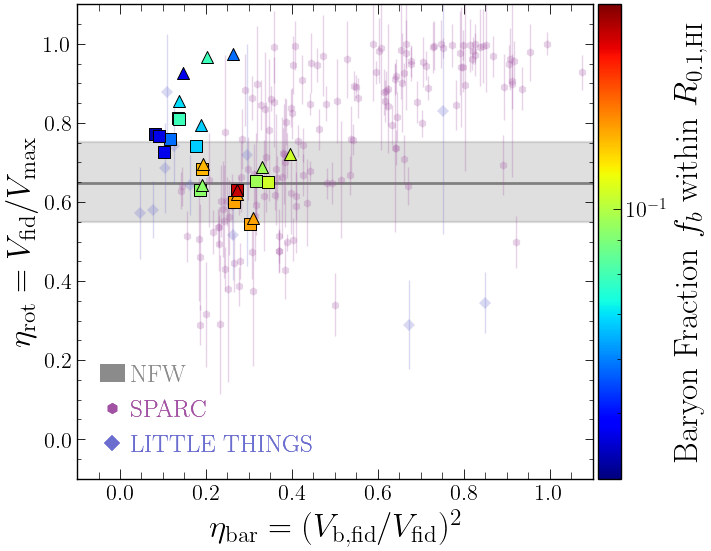

In [180]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sim_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
]
sim_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=8,
           markerfacecolor=sim_colors[i], markeredgecolor="none",
           label= (sim.name.split('-')[-1]) if i != 0 else "A-" + sim.name.split('-')[-1])
    for i, sim in enumerate(g4)
]

def make_eta_rot_eta_bar(get_radius_fn, label = r"$R_{\rm 1,gas}$", xlim = (-0.1,1.1), ylim = (-0.1,1.1), title=None, with_ax = None, use_arepo = False, plot_line = True, N = 0, draw_line = False, alpha_obs = 0.25, lw_sim = 0.7, cm_str = "jet", m_size = 75, draw_colorbar = True, use_sim_c = False, draw_sim_legend = True, draw_rad_legend = False, vfid_scale = 35, fsize = 24):
    if not with_ax:
        #fig, ax = plt.subplots(figsize=(7,6))
        fig = plt.figure(figsize=(7.1, 5.5), constrained_layout=True)
        if use_sim_c and draw_colorbar:
            fig.set_constrained_layout_pads(wspace=0.0, w_pad=0.0)
            sf_main, sf_leg = fig.subfigures(1, 2, width_ratios=[5, 1])
            ax = sf_main.subplots()
        else:
            ax = fig.subplots()
    else:
        ax = with_ax
        fig = with_ax.get_figure()
        if use_sim_c and draw_colorbar:
            divider = make_axes_locatable(ax)
            sf_leg = divider.append_axes("right", size="20%", pad=0.1)
            sf_leg.axis("off")
    
    #nfwx_m, nfwy_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Cruz25\\nfwmean.txt",delimiter=',', unpack=True)
    #nfwx_u, nfwy_u = np.loadtxt("C:\\Home\\Astro\\TFG\\Cruz25\\nfwup.txt",delimiter=',', unpack=True)
    #nfwx_d, nfwy_d = np.loadtxt("C:\\Home\\Astro\\TFG\\Cruz25\\nfwdown.txt",delimiter=',', unpack=True)
    #p, _ = np.polyfit(nfwx_m, nfwy_m, 1, cov=True)
    #m_nfw, _ = p
    #p, _ = np.polyfit(nfwx_u, nfwy_u, 1, cov=True)
    #m_nfw_u, _ = p
    #p, _ = np.polyfit(nfwx_d, nfwy_d, 1, cov=True)
    #m_nfw_d, _ = p
    #x = np.linspace(-10, 10, 300)
    #y      = m_nfw*np.ones_like(x)
    #y_up   = m_nfw_u*np.ones_like(x)
    #y_down = m_nfw_d*np.ones_like(x)
    #ax.fill_between(x, y_down, y_up, color="grey", alpha=0.25, label="NFW", zorder = -1)
    #ax.plot(x, y, color="grey", lw=2, zorder = -1, linestyle=":")
    N_nfw = 300
    x = np.linspace(-10, 10, N_nfw)
    # SS20 data
    ax.fill_between(x, [0.5498725416051882]*N_nfw, [0.752493018806912]*N_nfw, color="grey", alpha=0.25, label="NFW", zorder = -3)
    ax.plot(x, [0.6487307721660094]*N_nfw, color="grey", lw=2, zorder = -2, linestyle="-")

    lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500 and not np.isnan(g.eta_bar)]
    sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500 and not np.isnan(g.eta_bar)]
    
    ax.errorbar([g.eta_bar for g in lt_usable], [g.eta_rot for g in lt_usable], xerr=None, yerr=[g.e_eta_rot for g in lt_usable], marker = "D", label="LITTLE THINGS", color="#6b6ecf", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)
    ax.errorbar([g.eta_bar for g in sparc_gals_usable], [g.eta_rot for g in sparc_gals_usable], xerr=None, yerr=[g.e_eta_rot for g in sparc_gals_usable], marker = "h", label="SPARC", color="#a252a2", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)

    cmap = cm.get_cmap(cm_str)
    norm = mcolors.LogNorm(vmin=4e-2, vmax=2e-1)

    def eta_rot(s, radius):
        vmax = s.d.v_max(force_recompute=False, center = s.v.center, radius = radius, auto_save=False, particle="all", bins=50)
        vfid = s.d.v_fid(force_recompute=False, center = s.v.center, radius = vmax.to_value()/vfid_scale, auto_save=False, particle="all")
        return vfid / vmax

    def eta_bar(s, radius):
        vmax = s.d.v_max(force_recompute=False, center = s.v.center, radius = radius, auto_save=False, particle="all", bins=50)
        vfid = s.d.v_fid(force_recompute=False, center = s.v.center, radius = vmax.to_value()/vfid_scale, auto_save=False, particle="all")
        vbfid = s.d.v_fid(force_recompute=False, center = s.v.center, radius = vmax.to_value()/vfid_scale, auto_save=False, particle="baryon")
        return (vbfid / vfid)**2

    if plot_line:
        true_erot = []
        true_efid = []
        for i in range(len(g4)):
            s = g4[i].snap[0]
            min_rad = s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to_value()
            max_rad = s.v.r_virial.to_value()
            special_rad = np.array([s.v.r01_cgas.to_value(), s.v.r1_cgas.to_value()])
            eta_rot_values = []
            eta_bar_values = []
            radii = np.sort(np.concatenate([np.linspace(min_rad, max_rad, N), special_rad]))
            for j, radius in enumerate(radii):
                eta_rot_values.append(eta_rot(s, radius))
                eta_bar_values.append(eta_bar(s, radius)) # Use the eta_bar formula from SS20
            if draw_line:
                ax.plot(eta_rot_values, eta_bar_values, "-", color="#ad494a", label = "CROCODILE-DWARF" if i == 0 else None)
            j = np.searchsorted(radii, special_rad)
            colors = ["#6bc5cf", "#cf6bb9"]
            mk = ["s", "^"]
            true_erot.append(np.array(eta_rot_values)[j])
            true_efid.append(np.array(eta_bar_values)[j])
            baryon_fraction = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="baryon", auto_save=False)/s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="all", auto_save=False)
            for k, idx in enumerate(j):
                ax.scatter(eta_bar_values[idx], eta_rot_values[idx], s=m_size, marker = mk[k], color=cmap(norm(baryon_fraction)), zorder = 3, linewidth = lw_sim, edgecolors="black")

            g4[i].flush()

    #ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"$\eta_{\rm bar} = (V_{\rm b,fid}/V_{\rm fid})^2$", fontsize=fsize) 
    ax.set_ylabel(r"$\eta_{\rm rot} = V_{\rm fid}/V_{\rm max}$", fontsize=fsize)
    gal_handles = [
    Patch(facecolor='grey',edgecolor='none',alpha=0.7,label='NFW'),
    Line2D([], [], marker='h', linestyle='None', markersize=8,
           markerfacecolor='#a252a2', markeredgecolor='none',
           label='SPARC'),
    Line2D([], [], marker='D', linestyle='None', markersize=8,
           markerfacecolor='#6b6ecf', markeredgecolor='none',
           label='LITTLE THINGS')]
    if draw_sim_legend:
        leg1 = ax.legend(handles=gal_handles, fontsize=18, loc="lower left", handletextpad=0.25, handlelength = 1, labelcolor="mfc")
        ax.add_artist(leg1)

    rad_handles = [
        Line2D([], [], marker='s', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}$'),
        Line2D([], [], marker='^', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 1, HI}$')]
    if draw_rad_legend:
        ax.legend(handles=rad_handles, fontsize=18, loc="lower right", handletextpad=0.25, handlelength = 1)
    if use_sim_c and draw_colorbar:
        sf_leg.legend(handles=sim_handles, fontsize=15, loc="center", frameon=False, fancybox=True, framealpha=1, edgecolor="#3B3B3B", handletextpad=0.2, labelspacing=0.92, borderpad=0.4, borderaxespad=0, handlelength = 1)

    if draw_colorbar and not use_sim_c:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label(r"Baryon Fraction $f_b$ within $R_{\rm 0.1, HI}$", fontsize=fsize)
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())
    if title:
        ax.set_title(title, fontsize=16)

make_eta_rot_eta_bar(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True)


C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\793732289.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-07 18:34:52,130 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:52,133 Using cached value for 'v_max' [5cc4dba7] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:52,137 Using cached value for 'v_fid' [bedc7531] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:52,140 Using cached value for 'v_max' [3b41382d] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:52,143 Using cached value for 'v_fid' [3b2b5260] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:52,146 Using cached value for 'mass_in_sphere' [9c190a7f] at snapshot 0
Astroflow : [INFO] 2026-05-07 18:34:52,150 Using cached value for 'mass_

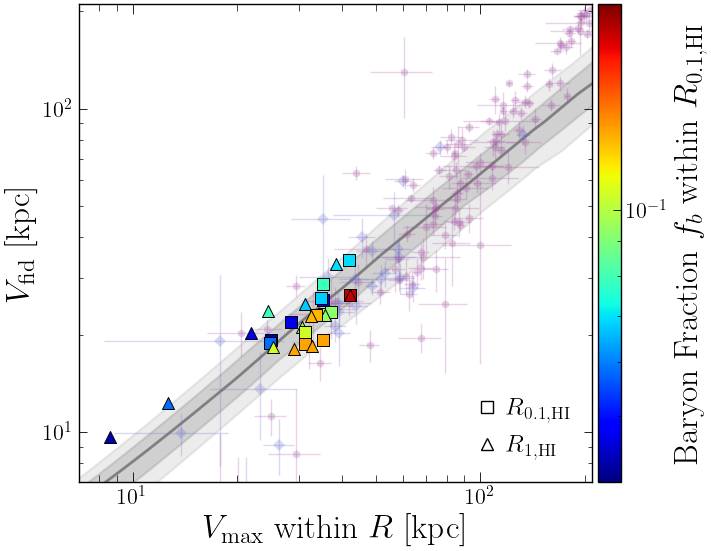

In [161]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sim_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
]
sim_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=8,
           markerfacecolor=sim_colors[i], markeredgecolor="none",
           label= (sim.name.split('-')[-1]) if i != 0 else "A-" + sim.name.split('-')[-1])
    for i, sim in enumerate(g4)
]

def make_vmax_vfid(get_radius_fn, label = r"$R_{\rm 1,gas}$", xlim = (7,210), ylim = (7,210), title=None, with_ax = None, use_arepo = False, plot_line = True, N = 0, draw_line = False, alpha_obs = 0.25, lw_sim = 0.7, cm_str = "jet", m_size = 75, draw_colorbar = True, use_sim_c = False, draw_sim_legend = False, draw_rad_legend = True, vfid_scale = 35, fsize = 24):
    if not with_ax:
        #fig, ax = plt.subplots(figsize=(7,6))
        fig = plt.figure(figsize=(7.1, 5.5), constrained_layout=True)
        if use_sim_c and draw_colorbar:
            fig.set_constrained_layout_pads(wspace=0.0, w_pad=0.0)
            sf_main, sf_leg = fig.subfigures(1, 2, width_ratios=[5, 1])
            ax = sf_main.subplots()
        else:
            ax = fig.subplots()
    else:
        ax = with_ax
        fig = with_ax.get_figure()
        if use_sim_c and draw_colorbar:
            divider = make_axes_locatable(ax)
            sf_leg = divider.append_axes("right", size="20%", pad=0.1)
            sf_leg.axis("off")
    
    #nfwx_m, nfwy_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Cruz25\\nfwmean.txt",delimiter=',', unpack=True)
    #nfwx_u, nfwy_u = np.loadtxt("C:\\Home\\Astro\\TFG\\Cruz25\\nfwup.txt",delimiter=',', unpack=True)
    #nfwx_d, nfwy_d = np.loadtxt("C:\\Home\\Astro\\TFG\\Cruz25\\nfwdown.txt",delimiter=',', unpack=True)
    #p, _ = np.polyfit(nfwx_m, nfwy_m, 1, cov=True)
    #m_nfw, b_nfw = p
    #p, _ = np.polyfit(nfwx_u, nfwy_u, 1, cov=True)
    #m_nfw_u, b_nfw_u = p
    #p, _ = np.polyfit(nfwx_d, nfwy_d, 1, cov=True)
    #m_nfw_d, b_nfw_d = p
    #x = np.linspace(0, 300, 300)
    #y      = m_nfw * x + b_nfw
    #y_up   = m_nfw_u * x + b_nfw_u
    #y_down = m_nfw_d * x + b_nfw_d
    #ax.fill_between(x, y_down, y_up, color="grey", alpha=0.25, label="NFW", zorder = -1)
    #ax.plot(x, y, color="grey", lw=2, zorder = -1, linestyle=":")

    x = np.linspace(0, 300, 300)
    nfw_x, nfw_y = np.loadtxt(r"C:\Home\Astro\TFG\Data\Observations\NFW_SS20.txt",delimiter=',', unpack=True)
    nfw_90_u_x, nfw_90_u_y = np.loadtxt(r"C:\Home\Astro\TFG\Data\Observations\NFW_P90_UP_SS20.txt",delimiter=',', unpack=True)
    nfw_90_d_x, nfw_90_d_y = np.loadtxt(r"C:\Home\Astro\TFG\Data\Observations\NFW_P90_DOWN_SS20.txt",delimiter=',', unpack=True)
    nfw_99_u_x, nfw_99_u_y = np.loadtxt(r"C:\Home\Astro\TFG\Data\Observations\NFW_P99_UP_SS20.txt",delimiter=',', unpack=True)
    nfw_99_d_x, nfw_99_d_y = np.loadtxt(r"C:\Home\Astro\TFG\Data\Observations\NFW_P99_DOWN_SS20.txt",delimiter=',', unpack=True)

    #y_d_90 = np.interp(x, nfw_90_d_x, nfw_90_d_y)
    #y_d_99 = np.interp(x, nfw_99_d_x, nfw_99_d_y)
    #y_m = np.interp(x, nfw_x, nfw_y)
    #y_u_90 = np.interp(x, nfw_90_u_x, nfw_90_u_y)
    #y_u_99 = np.interp(x, nfw_99_u_x, nfw_99_u_y)

    def interp_extrap(x_new, x_old, y_old):
        idx = np.argsort(x_old)
        f = interp1d(np.asarray(x_old)[idx], np.asarray(y_old)[idx],
                    kind="linear", fill_value="extrapolate")
        return f(x_new)

    y_d_90 = interp_extrap(x, nfw_90_d_x, nfw_90_d_y)
    y_d_99 = interp_extrap(x, nfw_99_d_x, nfw_99_d_y)
    y_m    = interp_extrap(x, nfw_x,      nfw_y)
    y_u_90 = interp_extrap(x, nfw_90_u_x, nfw_90_u_y)
    y_u_99 = interp_extrap(x, nfw_99_u_x, nfw_99_u_y)

    ax.plot(x, y_m, color="grey", lw=2, zorder = -2, linestyle="-")
    ax.fill_between(x, y_d_90, y_u_90, color="grey", alpha=0.25, zorder = -3)
    ax.fill_between(x, y_d_99, y_u_99, color="grey", alpha=0.15, zorder = -3)

    lt_usable = [g for g in lt_galaxies if not np.isnan(g.eta_rot) and g.v_max < 500]
    sparc_gals_usable = [g for g in sparc_galaxies if not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 500]
    
    ax.errorbar([g.v_max for g in lt_usable], [g.v_fid for g in lt_usable], xerr=[g.e_v_max for g in lt_usable], yerr=[g.e_v_fid for g in lt_usable], marker = "D", label="LITTLE THINGS", color="#6b6ecf", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)
    ax.errorbar([g.v_max for g in sparc_gals_usable], [g.v_fid for g in sparc_gals_usable], xerr=[g.e_v_max for g in sparc_gals_usable], yerr=[g.e_v_fid for g in sparc_gals_usable], marker = "h", label="SPARC", color="#a252a2", linestyle="None", elinewidth=1, alpha = alpha_obs, markeredgewidth=0, zorder = 0)

    def v_max_fn(s, radius):
        return s.d.v_max(force_recompute=False, center = s.v.center, radius = radius, auto_save=True, particle="all", bins=50)
    
    def v_fid_fn(s, radius):
        return s.d.v_fid(force_recompute=False, center = s.v.center, radius = radius, auto_save=True, particle="all")

    cmap = cm.get_cmap(cm_str)
    norm = mcolors.LogNorm(vmin=4e-2, vmax=2e-1)
    if plot_line:
        true_vm = []
        true_vf = []
        for i in range(len(g4)):
            s = g4[i].snap[0]
            min_rad = s.d.min_radius(force_recompute=False, center=s.v.center, particle="all", N=1000, tol=10).to_value()
            max_rad = s.v.r_virial.to_value()
            special_rad = np.array([s.v.r01_cgas.to_value(), s.v.r1_cgas.to_value()])
            v_max_values = []
            v_fid_values = []
            radii = np.sort(np.concatenate([np.linspace(min_rad, max_rad, N), special_rad]))
            for j, radius in enumerate(radii):
                v_max_values.append(v_max_fn(s, radius))
                v_fid_values.append(v_fid_fn(s, v_max_values[-1].to_value()/vfid_scale)) # Use the vfid formula from SS20
            if draw_line:
                ax.plot(v_max_values, v_fid_values, "-", color="#ad494a", label = "CROCODILE-DWARF" if i == 0 else None)
            j = np.searchsorted(radii, special_rad)
            colors = ["#6bc5cf", "#cf6bb9"]
            mk = ["s", "^"]
            true_vm.append(np.array(v_max_values)[j])
            true_vf.append(np.array(v_fid_values)[j])
            baryon_fraction = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="baryon", auto_save=True)/s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = s.v.r01_cgas.to_value(), particle="all", auto_save=True)
            for k, idx in enumerate(j):
                ax.scatter(v_max_values[idx], v_fid_values[idx], s=m_size, marker = mk[k], color=cmap(norm(baryon_fraction)), zorder = 3, linewidth = lw_sim, edgecolors="black")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"$V_{\rm max}$ within $R$ [kpc]", fontsize=fsize) 
    ax.set_ylabel(r"$V_{\rm fid}$ [kpc]", fontsize=fsize)
    gal_handles = [
    Line2D([], [], marker='D', linestyle='None', markersize=8,
           markerfacecolor='#6b6ecf', markeredgecolor='none',
           label='LITTLE THINGS'),
    Line2D([], [], marker='h', linestyle='None', markersize=8,
           markerfacecolor='#a252a2', markeredgecolor='none',
           label='SPARC'),
    Patch(facecolor='grey',edgecolor='none',alpha=0.7,label='NFW')]
    if draw_sim_legend:
        leg1 = ax.legend(handles=gal_handles, fontsize=18, loc="upper left", handletextpad=0.25, handlelength = 1, labelcolor="mfc")
        ax.add_artist(leg1)

    rad_handles = [
        Line2D([], [], marker='s', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 0.1, HI}$'),
        Line2D([], [], marker='^', linestyle='None', markersize=8,
            markerfacecolor='none', markeredgecolor="k",
            markeredgewidth=1, label=r'$R_{\rm 1, HI}$')]
    if draw_rad_legend:
        ax.legend(handles=rad_handles, fontsize=18, loc="lower right", handletextpad=0.25, handlelength = 1)
    if use_sim_c and draw_colorbar:
        sf_leg.legend(handles=sim_handles, fontsize=15, loc="center", frameon=False, fancybox=True, framealpha=1, edgecolor="#3B3B3B", handletextpad=0.2, labelspacing=0.92, borderpad=0.4, borderaxespad=0, handlelength = 1)
    if draw_colorbar and not use_sim_c:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label(r"Baryon Fraction $f_b$ within $R_{\rm 0.1, HI}$", fontsize=fsize)
        cbar.ax.yaxis.set_minor_formatter(NullFormatter())
    if title:
        ax.set_title(title, fontsize=fsize)

make_vmax_vfid(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True)


C:\Users\pablo\AppData\Local\Temp\ipykernel_214192\3382352178.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cm_str)
Astroflow : [INFO] 2026-05-16 02:30:26,557 Using cached value for 'min_radius' [c12907b1] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:30:26,559 Using cached value for 'v_max' [5cc4dba7] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:30:26,562 Using cached value for 'v_fid' [bedc7531] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:30:26,564 Using cached value for 'v_max' [5cc4dba7] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:30:26,566 Using cached value for 'v_fid' [bedc7531] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:30:26,568 Using cached value for 'v_fid' [a6b325cf] at snapshot 0
Astroflow : [INFO] 2026-05-16 02:30:26,571 Using cached value for 'v_max' [3b4138

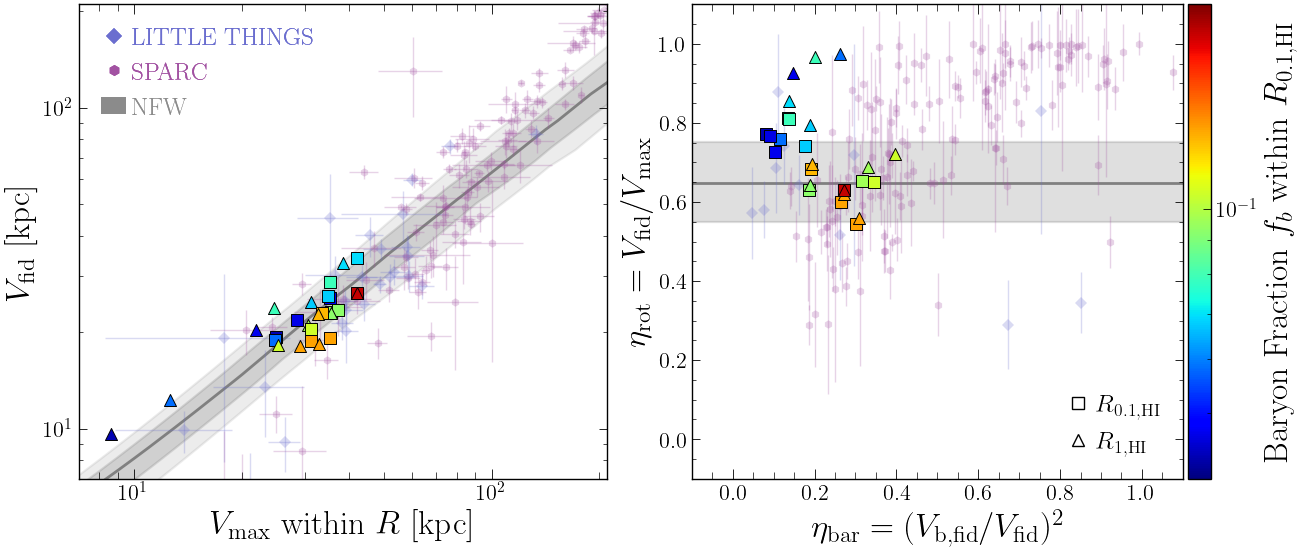

In [181]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True, width_ratios=[1,0.93])

make_eta_rot_eta_bar(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True, draw_colorbar=True, with_ax = ax[1], draw_sim_legend=False, draw_rad_legend=True, vfid_scale = 35)
make_vmax_vfid(lambda s: s.v.r01_cgas.to_value(), label = r"$R$", title=None, plot_line=True, draw_colorbar=False, with_ax = ax[0], draw_sim_legend=True, draw_rad_legend=False, vfid_scale = 35)

fig.savefig(r"C:\Home\Astro\TFG\Figures\Draft\Diversity_v.png", dpi=300)


(0.0, 60.0)

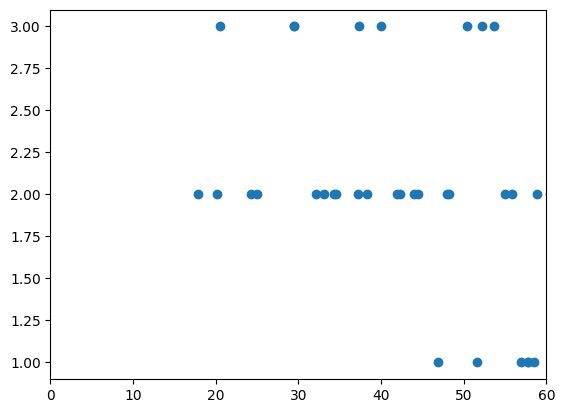

In [ ]:
def extr(attr): return np.array([getattr(g, attr) for g in galaxies])
    
v_max, Q = extr('v_max'), extr('quality')

plt.scatter(v_max, Q)
plt.xlim(0, 60)



In [ ]:
def plot_relations(galaxies):
    gals =[g for g in galaxies if g.quality < 4 and not np.isnan(g.eta_rot) and g.inclination > 30 and g.v_max < 60]
    
    def extr(attr): return np.array([getattr(g, attr) for g in gals])
    
    # Extract Values & Errors
    v_max, e_v_max = extr('v_max'), extr('e_v_max')
    m_bar, e_m_bar = extr('m_bar'), extr('e_m_bar')
    m_star, e_m_star = extr('m_star'), extr('e_m_star')
    m_hi = extr('MHI')
    r_hi = extr('RHI')
    v_fid, e_v_fid = extr('v_fid'), extr('e_v_fid')
    eta_rot, e_eta_rot = extr('eta_rot'), extr('e_eta_rot')
    eta_bar = extr('eta_bar')
    r_1_2 = extr('r_1_2_star')
    
    _, axes = plt.subplots(3, 3, figsize=(15, 15))
    
    def plot_err(ax, x, y, xerr, yerr, c, title, xlab, ylab, logx=False, logy=False):
        # Force absolute values to prevent negative errors from linear extrapolation
        xerr = [np.abs(err) for err in xerr] if xerr is not None else None
        yerr = [np.abs(err) for err in yerr] if yerr is not None else None
        
        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', markerfacecolor=c, 
                    markeredgecolor='k', ecolor='gray', elinewidth=1, alpha=0.8, capsize=0)
        if logx: ax.set_xscale('log')
        if logy: ax.set_yscale('log')
        ax.set_title(title)
        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)

    # 1. Mbar vs Vmax
    plot_err(axes[0,0], v_max, m_bar, e_v_max, e_m_bar, 'steelblue', 'Baryonic Tully-Fisher', r'$V_{max}$ [km/s]', r'$M_{bar}$ [$M_\odot$]', True, True)
    
    # 2. M_HI vs Mstar
    plot_err(axes[0,1], m_star, m_hi, e_m_star, None, 'coral', r'$M_{HI}$ vs $M_{star}$', r'$M_{star}$ [$M_\odot$]', r'$M_{HI}$[$M_\odot$]', True, True)
    
    # 3. MHI vs RHI
    plot_err(axes[0,2], r_hi, m_hi, None, None, 'mediumseagreen', r'$M_{HI}$ vs $R_{HI}$', r'$R_{HI}$ [kpc]', r'$M_{HI}$ [$M_\odot$]', True, True)
    
    # 4. Vfid vs Vmax
    plot_err(axes[1,0], v_max, v_fid, e_v_max, e_v_fid, 'darkorchid', r'$V_{fid}$ vs $V_{max}$', r'$V_{max}$[km/s]', r'$V_{fid}$ (at 2 kpc)[km/s]')
    axes[1,0].plot([0, 70], [0, 70], 'k--', alpha=0.5)
    
    # 5. eta_rot vs eta_bar
    plot_err(axes[1,1], eta_bar, eta_rot, None, e_eta_rot, 'gold', r'$\eta_{rot}$ vs $\eta_{bar}$ (Santos-Santos+20)', r'$\eta_{bar}$', r'$\eta_{rot}$')
    axes[1,1].plot([0,1.2], [0,1.2], 'k--', alpha=0.5)
    
    # 6. R_1/2 vs M_star
    plot_err(axes[1,2], m_star, r_1_2, e_m_star, None, 'orchid', r'$R_{1/2}$ vs $M_{\star}$', r'$M_{star}$ [$M_\odot$]', r'$R_{1/2} \ (R_{eff})$ [kpc]', logx = True, logy = True)
    #axes[1,2].plot([0, 12], [0, 12], 'k--', alpha=0.5)

    def extr_list(attr): return [getattr(g, attr) for g in gals]
    rad = extr_list('rad_profile')
    circ_v = extr_list('v_obs_profile')
    circ_v_e = extr_list('e_v_obs_profile')
    bar_v = extr_list('v_bar_profile')
    _, ax_new = plt.subplots(figsize=(8,6))
    for i in range(len(gals)):
        plot_err(ax_new, rad[i], circ_v[i], None, circ_v_e[i], 'steelblue', 'Rotation Curves with Error Bars', r'Radius [kpc]', r'Circular Velocity [km/s]')
        print("\n---\n")
        print("Galaxy:", gals[i].name)
        print(np.abs(v_max[i] - np.nanmax(circ_v[i])), np.abs(v_max[i] - np.nanmax(circ_v[i]))/v_max[i])
        print(v_fid[i], eta_rot[i], v_fid[i]/np.nanmax(circ_v[i]))

        mask_r = rad[i] <= r_hi[i]
        if mask_r.sum() > 0:
            vmax_rhi = np.nanmax(circ_v[i][mask_r])
            print("Vmax at RHI:", vmax_rhi, "Difference to Vmax:", vmax_rhi-v_max[i], "RHI:", r_hi[i], "Radial points outside RHI:", rad[i][~mask_r])
        else:
            print("No valid points within RHI for this galaxy.")
            print("RHI:", r_hi[i], "Radial points:", rad[i])
        plot_err(ax_new, rad[i], bar_v[i], None, None, 'lightgray', 'Baryonic Rotation Curves', r'Radius [kpc]', r'Circular Velocity [km/s]')
    
    lt_gals = [g for g in galaxies if g.name.endswith('(LT)')]
    def extr_lt(attr): return np.array([getattr(g, attr) for g in lt_gals])
    alpha, e_alpha = extr_lt('alpha'), extr_lt('e_alpha')
    eta_rot = extr_lt('eta_rot')
    e_eta_rot = extr_lt('e_eta_rot')
    ratio = extr_lt('m_star') / extr_lt('m_halo')
    r_alpha = np.array([g.rad_dens_profile[0] for g in lt_gals])
    # 7. eta_rot vs alpha
    plot_err(axes[2,0], alpha, eta_rot, e_alpha, e_eta_rot, 'tomato', r'$\eta_{rot}$ vs $\alpha$', r'$\alpha$ (Inner logarithmic slope)', r'$\eta_{rot}$')
    # 8. alpha vs Mstar / Mhalo
    plot_err(axes[2,1], ratio, alpha, None, e_alpha, 'crimson', r'$\alpha$ vs $M_{star} / M_{halo}$', r'$M_{star} / M_{halo}^{dyn}$ (Proxy)', r'$\alpha$', True, False)
    # 9. alpha vs R_inner
    plot_err(axes[2,2], r_alpha, alpha, None, e_alpha, 'teal', r'$\alpha$ vs $R_{inner}$', r'$R_{inner}$ [kpc]', r'$\alpha$', True, False)
    
    plt.tight_layout()
    plt.show()

plot_relations(observed_galaxies)

In [ ]:
def make_btfr_plot(get_radius_fn, label = r"$R_{\rm 1,gas}$", xlim = (8,210), ylim = (5e5,1e10), title=None, v_max_fn = None, with_ax = None):
    if not with_ax:
        fig, ax = plt.subplots(figsize=(7,6))
    else:
        ax = with_ax

    things_btfr_v, things_btfr_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Oman19\\BTFR_THINGS.txt",delimiter=',', unpack=True)
    lthings_btfr_v, lthings_btfr_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Oman19\\BTFR_LITTLETHINGS.txt",delimiter=',', unpack=True)
    sparc_btfr_v, sparc_btfr_m = np.loadtxt("C:\\Home\\Astro\\TFG\\Oman19\\BTFR_SPARC.txt",delimiter=',', unpack=True)

    ax.scatter(things_btfr_v, things_btfr_m, s=120, marker = "s", label="THINGS", color="#6b6ecf")
    ax.scatter(lthings_btfr_v, lthings_btfr_m, s=120, marker = "D", label="LITTLE THINGS", color="#6b6ecf")
    ax.scatter(sparc_btfr_v, sparc_btfr_m, s=80, marker = "h", label="SPARC", color="#a252a2")

    def get_mass(s):
        mgas = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = get_radius_fn(s), particle="PartType4", auto_save=True)
        mstar = s.d.mass_in_sphere(force_recompute=False, center = s.v.center, radius = get_radius_fn(s), particle="PartType0", auto_save=True)
        return mgas + mstar

    if v_max_fn is None:
        def v_max_fn(s):
            return s.d.v_max(force_recompute=False, center = s.v.center, radius = get_radius_fn(s), auto_save=True, particle="all", bins=50)

    g4_v_max = [v_max_fn(sim.snap[0]) for sim in g4]
    g4_mbar = [get_mass(sim.snap[0]) for sim in g4]
    arepo_v_max = [v_max_fn(sim.snap[0]) for sim in arepo]
    arepo_mbar = [get_mass(sim.snap[0]) for sim in arepo]

    log.info("-- BTFR Data: --")
    log.info(f"Using G4 v_max: {g4_v_max}")
    log.info(f"Using AREPO v_max: {arepo_v_max}")
    log.info(f"Using G4 mbar: {g4_mbar}")
    log.info(f"Using AREPO mbar: {arepo_mbar}")

    ax.scatter(g4_v_max[2:], g4_mbar[2:], s=20, marker = "o", label="CROCODILE-DWARF", color="#ad494a") 
    ax.scatter(arepo_v_max, arepo_mbar, s=20, marker = "o", label="AREPO-T", color="#8ca252") 
        
    ax.scatter(g4_v_max[:2], g4_mbar[:2], s=50, marker = "o", color="#ad494a", linewidth=2, edgecolor="black") 
    ax.scatter(arepo_v_max[3], arepo_mbar[3], s=50, marker = "o", color="#8ca252", linewidth=2, edgecolor="black") 

    ax.set_xscale("log") 
    ax.set_yscale("log")
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.set_xlabel("$V_{\\rm max}$ [km/s]", fontsize=20) 
    ax.set_ylabel(rf"Baryonic Mass within {label}"+r"[$M_{\odot}$]", fontsize=20)
    ax.legend(fontsize=18, labelcolor="mfc", loc="upper left")
    if title:
        ax.set_title(title, fontsize=16)

make_btfr_plot(lambda s: s.v.r01_cgas.to_value(), label = r"$R_{\rm 01,cgas}$", title=r"BTFR using $R_{\rm 01,cgas}$")
make_btfr_plot(lambda s: s.v.r1_cgas.to_value(), label = r"$R_{\rm 1,cgas}$", title=r"BTFR using $R_{\rm 1,cgas}$")